# Decision Trees and Ensembles

The single most useful family of models for tabular data — and the one that still wins most Kaggle competitions that do not involve images or text.

The story has two halves. A single decision tree is **interpretable, needs no preprocessing, and handles anything you throw at it** — but it is also unstable and overfits badly. The second half is the discovery that this weakness is a *feature*: combine many unstable models cleverly and the instability cancels out, leaving something far stronger than any single model could be.

**Prerequisites:** the bias-variance trade-off, cross-validation, overfitting, precision/recall.

| Part | Topic |
|---|---|
| 1 | How a tree splits: impurity, information gain, and a CART implementation from scratch |
| 2 | Why a single tree overfits, and how to control it |
| 3 | Why ensembles work: the mathematics of averaging |
| 4 | Bagging and Random Forests, from scratch |
| 5 | Boosting: AdaBoost and gradient boosting, from scratch |
| 6 | The modern libraries, and which algorithm to reach for |
| 7 | **Six challenge problems** |
| 8 | Summary, exercises, resources |

## 0. Setup

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import time

np.random.seed(0)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

RED, BLUE, GREEN, PURPLE, ORANGE, GREY = ("#e05252", "#3a7ddc", "#2fa84f",
                                          "#7a4fbf", "#e08b2f", "#888888")
from matplotlib.colors import ListedColormap
CMAP_PTS = ListedColormap([RED, BLUE])
CMAP_BG = ListedColormap(["#f7d7d7", "#d7e2f7"])

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.datasets import make_moons, make_classification, load_breast_cancer, load_diabetes

import sklearn
print("numpy", np.__version__, "| sklearn", sklearn.__version__)

numpy 2.5.2 | sklearn 1.9.0


---

# Part 1 — How a decision tree works

## 1.1 The idea

A decision tree asks a sequence of yes/no questions about the features, and each answer sends you down a branch until you reach a leaf that holds the prediction.

```
                  petal length <= 2.45 ?
                   /                  \
                 yes                   no
                  |                     |
              [setosa]        petal width <= 1.75 ?
                                /              \
                          [versicolor]     [virginica]
```

Geometrically, each question is an **axis-aligned cut**, so a tree carves the feature space into rectangles and predicts a constant inside each one. That is the whole model — which immediately tells you its strengths and its limits:

* it can express any shape, given enough rectangles (non-linear, non-monotonic, interactions — all free),
* it cannot express a diagonal boundary efficiently, because every cut is parallel to an axis,
* it predicts a constant per region, so like k-NN it produces a **staircase** and cannot extrapolate.

## 1.2 Choosing a split: impurity

At each node we must pick one feature and one threshold. The rule: **choose the split that makes the children as pure as possible**, where "pure" means the labels inside are all the same.

Two standard measures for a node with class proportions $p_1, \dots, p_C$:

$$\text{Gini} = 1 - \sum_c p_c^2 \qquad\qquad \text{Entropy} = -\sum_c p_c \log_2 p_c$$

Both are 0 when the node is pure and maximal when the classes are balanced. Then we score a candidate split by how much impurity it removes — the **information gain**:

$$\text{gain} = I(\text{parent}) - \frac{m_L}{m}I(\text{left}) - \frac{m_R}{m}I(\text{right})$$

The children are weighted by size, so a split that isolates two samples perfectly does not beat one that cleans up half the data.

For **regression** the same scheme applies with variance (equivalently MSE) as the impurity: split to minimize the weighted variance of the children, and predict each leaf's mean.

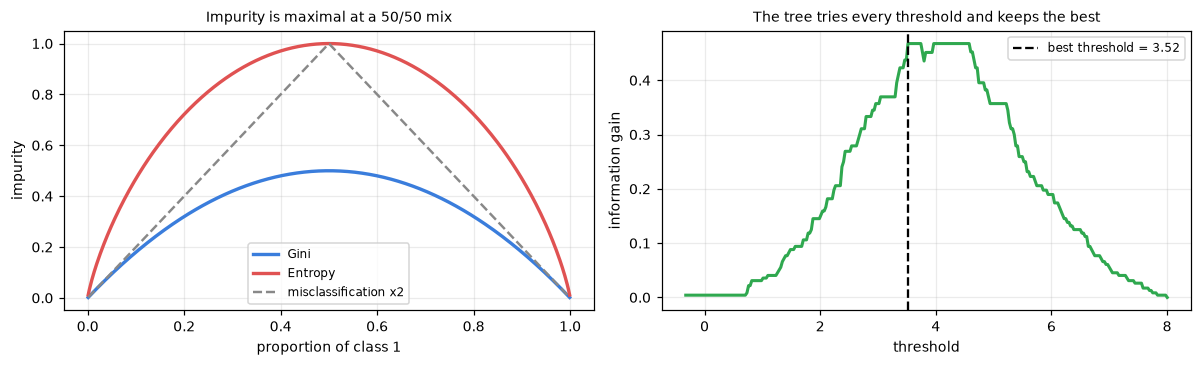

Gini and entropy almost always choose the same split - Gini is the default
because it avoids a logarithm and is therefore slightly faster.


In [6]:
def gini(y):
    if len(y) == 0:
        return 0.0
    p = np.bincount(y.astype(int)) / len(y)
    return 1.0 - np.sum(p ** 2)


def entropy(y):
    if len(y) == 0:
        return 0.0
    p = np.bincount(y.astype(int)) / len(y)
    p = p[p > 0]
    return -np.sum(p * np.log2(p))


def mse_impurity(y):
    return float(np.var(y)) if len(y) else 0.0


# the shape of the two criteria for a binary problem
p = np.linspace(0.001, 0.999, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(p, 1 - (p ** 2 + (1 - p) ** 2), color=BLUE, lw=2.2, label="Gini")
axes[0].plot(p, -(p * np.log2(p) + (1 - p) * np.log2(1 - p)), color=RED, lw=2.2, label="Entropy")
axes[0].plot(p, np.minimum(p, 1 - p) * 2, color=GREY, lw=1.6, ls="--", label="misclassification x2")
axes[0].set_xlabel("proportion of class 1"); axes[0].set_ylabel("impurity")
axes[0].set_title("Impurity is maximal at a 50/50 mix", fontsize=9); axes[0].legend(fontsize=8)

# information gain for every candidate threshold on a toy 1-D problem
rng = np.random.default_rng(0)
x1 = np.r_[rng.normal(2, 1, 60), rng.normal(6, 1, 60)]
yy = np.r_[np.zeros(60), np.ones(60)].astype(int)
thr = np.linspace(x1.min(), x1.max(), 300)
gains = []
for t in thr:
    L, R = yy[x1 <= t], yy[x1 > t]
    if len(L) == 0 or len(R) == 0:
        gains.append(0); continue
    gains.append(gini(yy) - (len(L) * gini(L) + len(R) * gini(R)) / len(yy))
axes[1].plot(thr, gains, color=GREEN, lw=2)
axes[1].axvline(thr[int(np.argmax(gains))], ls="--", color="k",
                label=f"best threshold = {thr[int(np.argmax(gains))]:.2f}")
axes[1].set_xlabel("threshold"); axes[1].set_ylabel("information gain")
axes[1].set_title("The tree tries every threshold and keeps the best", fontsize=9)
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print("Gini and entropy almost always choose the same split - Gini is the default")
print("because it avoids a logarithm and is therefore slightly faster.")

## 1.3 A CART implementation from scratch

The algorithm is recursive and short:

1. If a stopping rule fires (pure node, max depth, too few samples), make a leaf.
2. Otherwise search **every feature and every candidate threshold** for the split with the highest gain.
3. Recurse on the two halves.

That exhaustive search is why trees are called **greedy**: each split is chosen to be locally best, with no lookahead. Finding the globally optimal tree is NP-hard, and in practice the greedy version is good enough — especially once we start ensembling.

In [7]:
class Node:
    __slots__ = ("feature", "threshold", "left", "right", "value", "n_samples", "impurity")

    def __init__(self, **kw):
        for k in self.__slots__:
            setattr(self, k, kw.get(k))


class DecisionTree:
    """CART for classification and regression, written for clarity rather than speed."""

    def __init__(self, task="classification", criterion=None, max_depth=None,
                 min_samples_split=2, min_samples_leaf=1, min_impurity_decrease=0.0,
                 max_features=None, random_state=None):
        self.task = task
        self.criterion = criterion or ("gini" if task == "classification" else "mse")
        self.max_depth = max_depth if max_depth is not None else 2 ** 31
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.min_impurity_decrease = min_impurity_decrease
        self.max_features = max_features          # used by Random Forests, in Part 4
        self.random_state = random_state

    def _impurity(self, y):
        if self.task == "regression":
            return mse_impurity(y)
        return gini(y) if self.criterion == "gini" else entropy(y)

    def _leaf_value(self, y):
        if self.task == "regression":
            return float(np.mean(y))
        counts = np.bincount(y.astype(int), minlength=self.n_classes_)
        return counts / counts.sum()              # store the full distribution

    def _best_split(self, X, y, rng):
        m, n = X.shape
        parent = self._impurity(y)
        best = (None, None, 0.0)                  # feature, threshold, gain

        features = np.arange(n)
        if self.max_features is not None:         # the Random Forest trick
            k = self.max_features if isinstance(self.max_features, int) else \
                max(1, int(np.sqrt(n)))
            features = rng.choice(n, size=min(k, n), replace=False)

        for j in features:
            order = np.argsort(X[:, j])
            xs, ys = X[order, j], y[order]
            # only thresholds between two DIFFERENT feature values are candidates
            for i in range(self.min_samples_leaf, m - self.min_samples_leaf + 1):
                if xs[i] == xs[i - 1]:
                    continue
                left, right = ys[:i], ys[i:]
                gain = parent - (len(left) * self._impurity(left) +
                                 len(right) * self._impurity(right)) / m
                if gain > best[2]:
                    best = (j, (xs[i] + xs[i - 1]) / 2, gain)
        return best

    def _grow(self, X, y, depth, rng):
        node = Node(n_samples=len(y), impurity=self._impurity(y), value=self._leaf_value(y))

        if (depth >= self.max_depth or len(y) < self.min_samples_split
                or node.impurity == 0.0):
            return node

        j, t, gain = self._best_split(X, y, rng)
        if j is None or gain < self.min_impurity_decrease:
            return node

        mask = X[:, j] <= t
        node.feature, node.threshold = j, t
        node.left = self._grow(X[mask], y[mask], depth + 1, rng)
        node.right = self._grow(X[~mask], y[~mask], depth + 1, rng)
        return node

    def fit(self, X, y):
        X = np.asarray(X, dtype=float); y = np.asarray(y)
        self.n_features_ = X.shape[1]
        if self.task == "classification":
            self.classes_ = np.unique(y)
            self.n_classes_ = len(self.classes_)
            y = np.searchsorted(self.classes_, y)
        rng = np.random.default_rng(self.random_state)
        self.root_ = self._grow(X, y, 0, rng)
        return self

    def _predict_one(self, x, node):
        while node.feature is not None:
            node = node.left if x[node.feature] <= node.threshold else node.right
        return node.value

    def predict_proba(self, X):
        return np.array([self._predict_one(x, self.root_) for x in np.asarray(X, float)])

    def predict(self, X):
        out = self.predict_proba(X)
        return out if self.task == "regression" else self.classes_[out.argmax(1)]

    def score(self, X, y):
        if self.task == "regression":
            p = self.predict(X)
            return 1 - ((y - p) ** 2).sum() / ((y - np.mean(y)) ** 2).sum()
        return float(np.mean(self.predict(X) == y))

    def depth(self, node=None):
        node = node or self.root_
        if node.feature is None:
            return 0
        return 1 + max(self.depth(node.left), self.depth(node.right))

    def n_leaves(self, node=None):
        node = node or self.root_
        if node.feature is None:
            return 1
        return self.n_leaves(node.left) + self.n_leaves(node.right)

    def print_tree(self, node=None, depth=0, names=None, prefix="root"):
        node = node or self.root_
        pad = "   " * depth
        if node.feature is None:
            v = (f"{node.value:.2f}" if self.task == "regression"
                 else f"class {self.classes_[np.argmax(node.value)]} {np.round(node.value, 2)}")
            print(f"{pad}{prefix}: predict {v}   (n={node.n_samples})")
            return
        name = names[node.feature] if names else f"x{node.feature}"
        print(f"{pad}{prefix}: {name} <= {node.threshold:.3f}?   "
              f"(n={node.n_samples}, impurity={node.impurity:.3f})")
        self.print_tree(node.left, depth + 1, names, "yes")
        self.print_tree(node.right, depth + 1, names, "no")


from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()
Xi, yi = iris.data, iris.target
t = DecisionTree(max_depth=3).fit(Xi, yi)
t.print_tree(names=list(iris.feature_names))
print(f"\naccuracy ours   : {t.score(Xi, yi)*100:.2f}%")
print(f"accuracy sklearn: {DecisionTreeClassifier(max_depth=3, random_state=0).fit(Xi, yi).score(Xi, yi)*100:.2f}%")

root: petal length (cm) <= 2.450?   (n=150, impurity=0.667)
   yes: predict class 0 [1. 0. 0.]   (n=50)
   no: petal width (cm) <= 1.750?   (n=100, impurity=0.500)
      yes: petal length (cm) <= 4.950?   (n=54, impurity=0.168)
         yes: predict class 1 [0.   0.98 0.02]   (n=48)
         no: predict class 2 [0.   0.33 0.67]   (n=6)
      no: petal length (cm) <= 4.850?   (n=46, impurity=0.043)
         yes: predict class 2 [0.   0.33 0.67]   (n=3)
         no: predict class 2 [0. 0. 1.]   (n=43)

accuracy ours   : 97.33%
accuracy sklearn: 97.33%


Read that tree aloud and you have explained the model to a domain expert in three sentences. **This interpretability is the single biggest practical reason trees are still used**, in medicine, credit and law, where "the model said so" is not an acceptable answer.

## 1.4 What a tree's decision boundary looks like

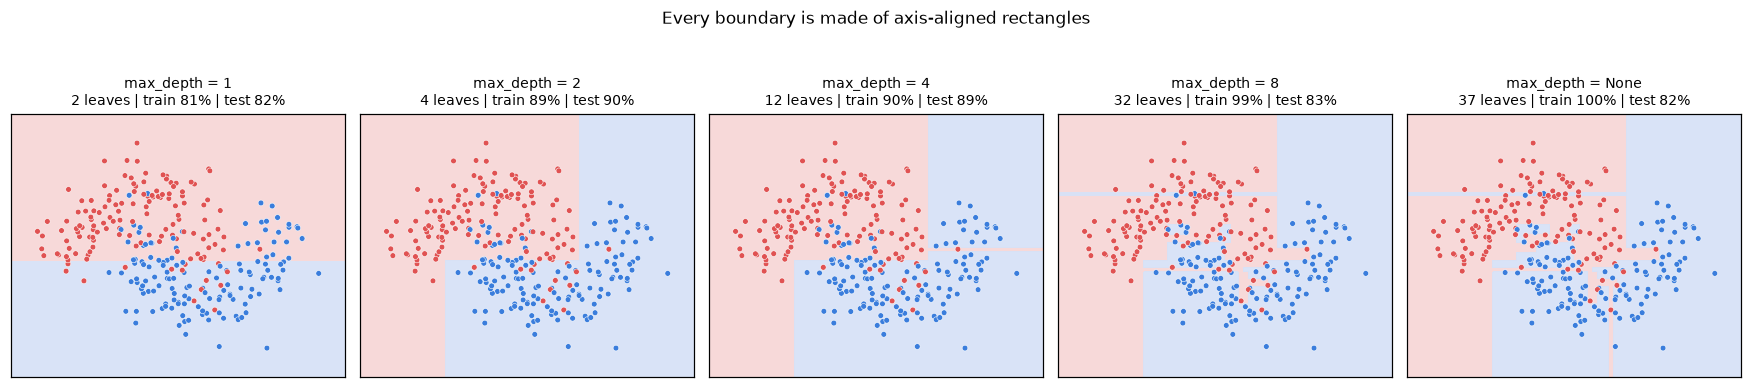

A depth-1 tree ('decision stump') is a single threshold on a single feature.
An unlimited tree keeps splitting until every leaf is pure - 100% training
accuracy, and a boundary full of thin slivers carved around individual points.


In [8]:
def plot_boundary(model, X, y, ax=None, title="", pad=0.4, res=300, proba=False):
    if ax is None:
        _, ax = plt.subplots(figsize=(4.6, 4.2))
    x0, x1 = X[:, 0].min() - pad, X[:, 0].max() + pad
    y0, y1 = X[:, 1].min() - pad, X[:, 1].max() + pad
    xx, yy = np.meshgrid(np.linspace(x0, x1, res), np.linspace(y0, y1, res))
    G = np.c_[xx.ravel(), yy.ravel()]
    if proba:
        Z = model.predict_proba(G)[:, 1].reshape(xx.shape)
        ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), cmap="RdBu_r", alpha=0.65)
    else:
        Z = model.predict(G).reshape(xx.shape)
        ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], cmap=CMAP_BG, alpha=0.95)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=CMAP_PTS, s=14, edgecolor="w", linewidth=0.35)
    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1); ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    return ax


Xm, ym = make_moons(n_samples=400, noise=0.30, random_state=0)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.3, random_state=0, stratify=ym)

fig, axes = plt.subplots(1, 5, figsize=(16, 3.3))
for ax, d in zip(axes, [1, 2, 4, 8, None]):
    m = DecisionTreeClassifier(max_depth=d, random_state=0).fit(Xm_tr, ym_tr)
    plot_boundary(m, Xm_tr, ym_tr, ax=ax,
                  title=f"max_depth = {d}\n{m.get_n_leaves()} leaves | "
                        f"train {m.score(Xm_tr, ym_tr)*100:.0f}% | test {m.score(Xm_te, ym_te)*100:.0f}%")
plt.suptitle("Every boundary is made of axis-aligned rectangles", y=1.05)
plt.tight_layout(); plt.show()

print("A depth-1 tree ('decision stump') is a single threshold on a single feature.")
print("An unlimited tree keeps splitting until every leaf is pure - 100% training")
print("accuracy, and a boundary full of thin slivers carved around individual points.")

## 1.5 Why a tree is a *high-variance* model

Trees have low bias — they can fit anything — and very high variance. The clearest demonstration is **instability**: change a handful of training points and the tree can come out completely different, because a slightly different split at the root propagates all the way down.

This looks like a fatal flaw. Part 3 turns it into the foundation of everything that follows.

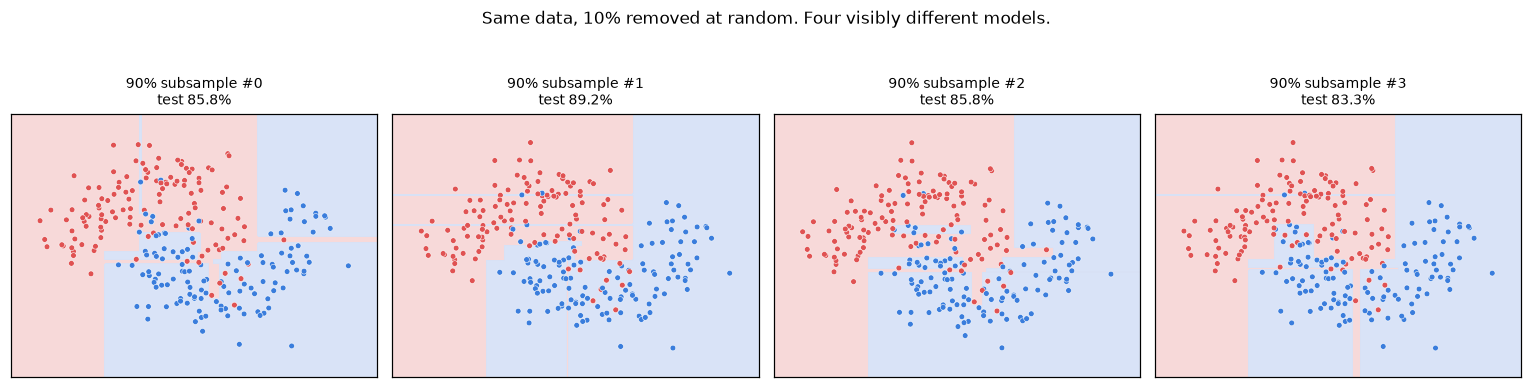

average disagreement between two such trees: 6.4% of test points
average individual accuracy               : 84.6%
accuracy of their MAJORITY VOTE           : 85.0%

That last line is the entire idea of the second half of this notebook.


In [9]:
rng = np.random.default_rng(1)
fig, axes = plt.subplots(1, 4, figsize=(14, 3.3))
for ax, seed in zip(axes, range(4)):
    idx = np.random.default_rng(seed).choice(len(ym_tr), int(0.9 * len(ym_tr)), replace=False)
    m = DecisionTreeClassifier(max_depth=6, random_state=0).fit(Xm_tr[idx], ym_tr[idx])
    plot_boundary(m, Xm_tr[idx], ym_tr[idx], ax=ax,
                  title=f"90% subsample #{seed}\ntest {m.score(Xm_te, ym_te)*100:.1f}%")
plt.suptitle("Same data, 10% removed at random. Four visibly different models.", y=1.05)
plt.tight_layout(); plt.show()

# quantify it: how often do two trees trained on 90% subsamples disagree?
preds = []
for seed in range(20):
    idx = np.random.default_rng(seed).choice(len(ym_tr), int(0.9 * len(ym_tr)), replace=False)
    preds.append(DecisionTreeClassifier(max_depth=6, random_state=0)
                 .fit(Xm_tr[idx], ym_tr[idx]).predict(Xm_te))
preds = np.array(preds)
disagree = np.mean([np.mean(preds[i] != preds[j])
                    for i in range(20) for j in range(i + 1, 20)])
print(f"average disagreement between two such trees: {disagree*100:.1f}% of test points")
print(f"average individual accuracy               : {np.mean([(p == ym_te).mean() for p in preds])*100:.1f}%")
print(f"accuracy of their MAJORITY VOTE           : "
      f"{np.mean((preds.mean(0) >= 0.5).astype(int) == ym_te)*100:.1f}%")
print("\nThat last line is the entire idea of the second half of this notebook.")

---

# Part 2 — Controlling a single tree

Left alone, a tree grows until every leaf is pure — a model with as many parameters as it needs to memorize the training set. Every knob below is a way of stopping that.

| Parameter | What it does | Typical values |
|---|---|---|
| `max_depth` | hard limit on the number of questions | 3–10; `None` = unlimited |
| `min_samples_split` | do not split a node with fewer samples | 2–50 |
| `min_samples_leaf` | every leaf must keep at least this many | **the most useful one**; 1–50 |
| `min_impurity_decrease` | ignore splits that gain less than this | small, e.g. 0.0–0.01 |
| `max_leaf_nodes` | cap the total number of leaves | an alternative to `max_depth` |
| `ccp_alpha` | cost-complexity pruning strength | tuned by CV |

The first five are **pre-pruning**: stop early. They are cheap but short-sighted, because a split that looks useless can enable an excellent one below it.

**Cost-complexity pruning** (`ccp_alpha`) is post-pruning and is the principled alternative: grow the full tree, then remove the subtrees whose contribution does not justify their size, by minimizing

$$R_\alpha(T) = R(T) + \alpha\,|\text{leaves}(T)|$$

That is exactly the shape of a regularized loss — error plus a penalty on complexity, with $\alpha$ playing the role of $\lambda$.

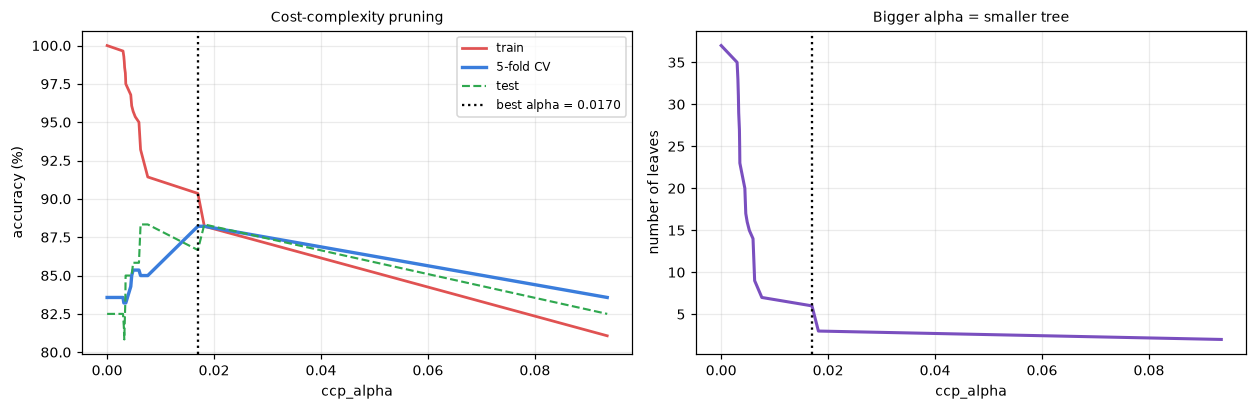

unpruned:  37 leaves, train 100.0%, test 82.5%
pruned  :   6 leaves, train 90.4%, test 86.7%

Smaller, more accurate, and readable. Note that training accuracy went DOWN
while test accuracy went UP - the definition of a good regularizer.


In [10]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

# the pruning path: sklearn computes every alpha at which the tree shrinks
full = DecisionTreeClassifier(random_state=0).fit(Xm_tr, ym_tr)
path = full.cost_complexity_pruning_path(Xm_tr, ym_tr)
alphas = path.ccp_alphas[:-1]                     # drop the trivial single-node tree

train_s, test_s, cv_s, leaves = [], [], [], []
for a in alphas:
    m = DecisionTreeClassifier(random_state=0, ccp_alpha=a).fit(Xm_tr, ym_tr)
    train_s.append(m.score(Xm_tr, ym_tr)); test_s.append(m.score(Xm_te, ym_te))
    cv_s.append(cross_val_score(DecisionTreeClassifier(random_state=0, ccp_alpha=a),
                                Xm_tr, ym_tr, cv=5).mean())
    leaves.append(m.get_n_leaves())

best_a = alphas[int(np.argmax(cv_s))]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
axes[0].plot(alphas, np.array(train_s) * 100, color=RED, lw=1.8, label="train")
axes[0].plot(alphas, np.array(cv_s) * 100, color=BLUE, lw=2.2, label="5-fold CV")
axes[0].plot(alphas, np.array(test_s) * 100, color=GREEN, lw=1.4, ls="--", label="test")
axes[0].axvline(best_a, ls=":", color="k", label=f"best alpha = {best_a:.4f}")
axes[0].set_xlabel("ccp_alpha"); axes[0].set_ylabel("accuracy (%)"); axes[0].legend(fontsize=8)
axes[0].set_title("Cost-complexity pruning", fontsize=9)
axes[1].plot(alphas, leaves, color=PURPLE, lw=2)
axes[1].axvline(best_a, ls=":", color="k")
axes[1].set_xlabel("ccp_alpha"); axes[1].set_ylabel("number of leaves")
axes[1].set_title("Bigger alpha = smaller tree", fontsize=9)
plt.tight_layout(); plt.show()

pruned = DecisionTreeClassifier(random_state=0, ccp_alpha=best_a).fit(Xm_tr, ym_tr)
print(f"unpruned: {full.get_n_leaves():>3} leaves, train {full.score(Xm_tr, ym_tr)*100:.1f}%, "
      f"test {full.score(Xm_te, ym_te)*100:.1f}%")
print(f"pruned  : {pruned.get_n_leaves():>3} leaves, train {pruned.score(Xm_tr, ym_tr)*100:.1f}%, "
      f"test {pruned.score(Xm_te, ym_te)*100:.1f}%")
print("\nSmaller, more accurate, and readable. Note that training accuracy went DOWN")
print("while test accuracy went UP - the definition of a good regularizer.")

## 2.1 What trees do and do not need

**No preprocessing required**, and this is a genuine, underrated advantage:

* **No scaling.** A split is a threshold on one feature; multiplying that feature by 1000 moves the threshold and changes nothing else. (Contrast with k-NN and SVM, where scaling was mandatory.)
* **Monotone transformations are invisible.** Taking a log of a feature does not change any split, because the ordering is unchanged.
* **Outliers matter little** in the features (they just end up in their own leaf) — though they still hurt regression trees through the leaf means.
* **Missing values** are handled natively by modern implementations (`HistGradientBoosting`, LightGBM, XGBoost) by learning which way to send them.
* **Categorical features** need encoding in scikit-learn, but beware: one-hot encoding a high-cardinality feature is bad for trees, because each binary column can only make one weak split. Prefer native categorical support or ordinal/target encoding.

**Two things trees genuinely cannot do:**

* **Diagonal boundaries.** A line at 45° needs an infinite staircase of axis-aligned cuts.
* **Extrapolation.** Outside the training range the prediction is a constant, exactly as with k-NN.

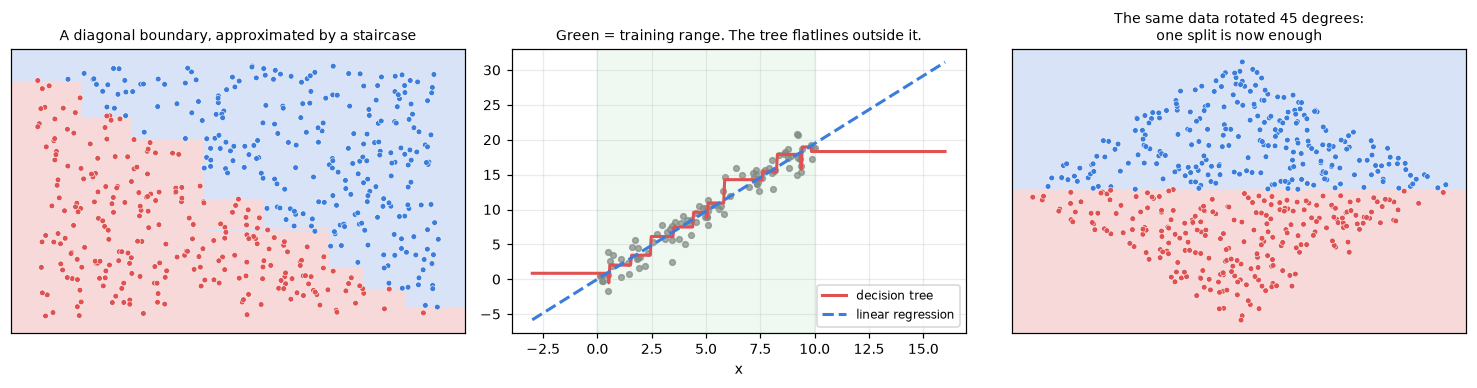

Trees are not rotation-invariant. That is why feature engineering that creates
the RIGHT axes (ratios, differences, sums) can help a tree enormously - it is
the tree equivalent of the polynomial features from the regression notebook.


In [11]:
# the two structural weaknesses, side by side
rng = np.random.default_rng(2)
Xd = rng.uniform(-3, 3, size=(500, 2))
yd = (Xd[:, 0] + Xd[:, 1] > 0).astype(int)        # a perfect diagonal boundary

xr = np.sort(rng.uniform(0, 10, 100))
yr = 2 * xr + rng.normal(0, 1.5, 100)             # a perfect linear trend
grid = np.linspace(-3, 16, 400).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6))
plot_boundary(DecisionTreeClassifier(max_depth=8, random_state=0).fit(Xd, yd), Xd, yd,
              ax=axes[0], title="A diagonal boundary, approximated by a staircase")

from sklearn.linear_model import LinearRegression
axes[1].scatter(xr, yr, s=14, color=GREY, alpha=0.7)
axes[1].plot(grid, DecisionTreeRegressor(max_depth=4).fit(xr.reshape(-1, 1), yr).predict(grid),
             color=RED, lw=2, label="decision tree")
axes[1].plot(grid, LinearRegression().fit(xr.reshape(-1, 1), yr).predict(grid),
             color=BLUE, lw=2, ls="--", label="linear regression")
axes[1].axvspan(0, 10, color=GREEN, alpha=0.07)
axes[1].set_title("Green = training range. The tree flatlines outside it.", fontsize=9)
axes[1].legend(fontsize=8); axes[1].set_xlabel("x")

# but rotate the data 45 degrees and the tree is suddenly fine
theta = np.pi / 4
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
plot_boundary(DecisionTreeClassifier(max_depth=8, random_state=0).fit(Xd @ R.T, yd), Xd @ R.T, yd,
              ax=axes[2], title="The same data rotated 45 degrees:\none split is now enough")
plt.tight_layout(); plt.show()

print("Trees are not rotation-invariant. That is why feature engineering that creates")
print("the RIGHT axes (ratios, differences, sums) can help a tree enormously - it is")
print("the tree equivalent of the polynomial features from the regression notebook.")

---

# Part 3 — Why ensembles work

## 3.1 The averaging argument

Suppose we have $B$ models, each with variance $\sigma^2$, and we average their predictions. If the models were **independent**, the variance of the average would be

$$\text{Var}\left(\frac{1}{B}\sum_b f_b\right) = \frac{\sigma^2}{B}$$

— variance divided by $B$, bias unchanged. That is an enormous win: it removes exactly the weakness of a single tree while keeping its strength.

Real models trained on the same data are not independent. With pairwise correlation $\rho$ the formula becomes

$$\rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$$

Look carefully at that expression, because it contains the design of every ensemble method:

* the second term vanishes as $B \to \infty$ — **more models always help, and never hurt**,
* the first term does **not** vanish. The floor is set by how correlated the models are.

> **Therefore: to improve an ensemble, either add more models, or make the models less correlated.** Bagging attacks $\rho$ by varying the data. Random forests attack it harder by also varying the features. Boosting takes an entirely different route.

Let's verify the formula numerically.

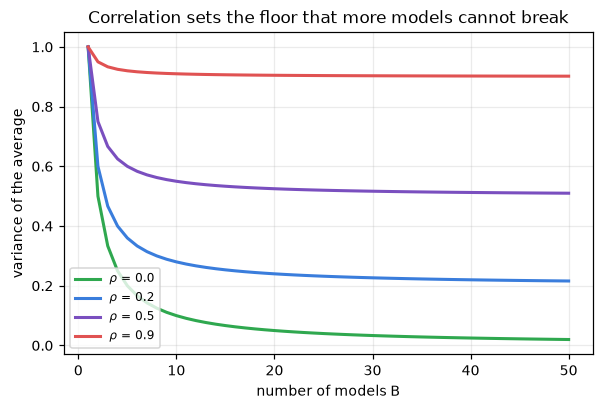

average accuracy of ONE tree      : 83.30%
best single tree                  : 86.08%
majority vote of  1 trees          : 83.83%
majority vote of  5 trees          : 87.17%
majority vote of 10 trees          : 86.67%
majority vote of 25 trees          : 87.50%
majority vote of 50 trees          : 87.42%

average pairwise correlation between the trees' outputs: 0.716
Lower that number and the ensemble improves further - which is exactly
what Random Forests are designed to do.


In [12]:
def ensemble_variance_demo(rho, sigma=1.0, Bs=range(1, 51)):
    return [rho * sigma ** 2 + (1 - rho) * sigma ** 2 / B for B in Bs]

Bs = list(range(1, 51))
plt.figure(figsize=(6.2, 3.8))
for rho, col in [(0.0, GREEN), (0.2, BLUE), (0.5, PURPLE), (0.9, RED)]:
    plt.plot(Bs, ensemble_variance_demo(rho, Bs=Bs), color=col, lw=2, label=f"$\\rho$ = {rho}")
plt.xlabel("number of models B"); plt.ylabel("variance of the average")
plt.title("Correlation sets the floor that more models cannot break")
plt.legend(fontsize=8); plt.show()

# and empirically, with real trees
rng = np.random.default_rng(0)
X_big, y_big = make_moons(n_samples=3000, noise=0.35, random_state=0)
Xa, Xb_, ya, yb_ = train_test_split(X_big, y_big, test_size=0.4, random_state=0)

preds = []
for b in range(50):
    idx = rng.choice(len(ya), len(ya), replace=True)          # bootstrap sample
    preds.append(DecisionTreeClassifier(random_state=b).fit(Xa[idx], ya[idx]).predict_proba(Xb_)[:, 1])
preds = np.array(preds)

singles = [(p >= 0.5).astype(int) for p in preds]
print(f"average accuracy of ONE tree      : {np.mean([(s == yb_).mean() for s in singles])*100:.2f}%")
print(f"best single tree                  : {max((s == yb_).mean() for s in singles)*100:.2f}%")
for B in [1, 5, 10, 25, 50]:
    ens = (preds[:B].mean(0) >= 0.5).astype(int)
    print(f"majority vote of {B:>2} trees          : {(ens == yb_).mean()*100:.2f}%")

corr = np.corrcoef(preds)[np.triu_indices(50, 1)].mean()
print(f"\naverage pairwise correlation between the trees' outputs: {corr:.3f}")
print("Lower that number and the ensemble improves further - which is exactly")
print("what Random Forests are designed to do.")

## 3.2 Bagging

**B**ootstrap **agg**regat**ing**, from Breiman (1996):

1. draw $B$ **bootstrap samples** — sample $m$ points *with replacement* from the training set,
2. fit one unpruned tree on each,
3. average the predictions (or vote).

Bootstrapping is what decorrelates the trees: each sees a different ~63% of the data. (Why 63%? The chance a given sample is never drawn in $m$ tries is $(1-1/m)^m \to e^{-1} \approx 0.368$.)

That leftover 37% is a free gift: the **out-of-bag (OOB) samples**. Each point can be predicted by the trees that never saw it, giving an unbiased estimate of test error **without any cross-validation**.

In [13]:
class Bagging:
    """Bagging of decision trees, written out."""

    def __init__(self, n_estimators=50, max_features=None, task="classification",
                 max_depth=None, random_state=0, **tree_kw):
        self.n_estimators, self.max_features = n_estimators, max_features
        self.task, self.max_depth, self.random_state = task, max_depth, random_state
        self.tree_kw = tree_kw

    def fit(self, X, y):
        X, y = np.asarray(X, float), np.asarray(y)
        m = len(y)
        rng = np.random.default_rng(self.random_state)
        self.trees_, self.oob_masks_ = [], []
        self.classes_ = np.unique(y) if self.task == "classification" else None

        for b in range(self.n_estimators):
            idx = rng.integers(0, m, m)                     # bootstrap: WITH replacement
            oob = np.ones(m, dtype=bool); oob[idx] = False
            Tree = (DecisionTreeClassifier if self.task == "classification"
                    else DecisionTreeRegressor)
            t = Tree(max_depth=self.max_depth, max_features=self.max_features,
                     random_state=int(rng.integers(1 << 30)), **self.tree_kw)
            self.trees_.append(t.fit(X[idx], y[idx]))
            self.oob_masks_.append(oob)

        self.oob_score_ = self._oob_score(X, y)
        return self

    def _oob_score(self, X, y):
        """Predict each sample using only the trees that never saw it."""
        m = len(y)
        if self.task == "regression":
            tot, cnt = np.zeros(m), np.zeros(m)
            for t, oob in zip(self.trees_, self.oob_masks_):
                tot[oob] += t.predict(X[oob]); cnt[oob] += 1
            ok = cnt > 0
            pred = tot[ok] / cnt[ok]
            return 1 - ((y[ok] - pred) ** 2).sum() / ((y[ok] - y[ok].mean()) ** 2).sum()
        votes = np.zeros((m, len(self.classes_)))
        for t, oob in zip(self.trees_, self.oob_masks_):
            votes[oob] += t.predict_proba(X[oob])
        ok = votes.sum(1) > 0
        return float(np.mean(self.classes_[votes[ok].argmax(1)] == y[ok]))

    def predict_proba(self, X):
        return np.mean([t.predict_proba(X) for t in self.trees_], axis=0)

    def predict(self, X):
        if self.task == "regression":
            return np.mean([t.predict(X) for t in self.trees_], axis=0)
        return self.classes_[self.predict_proba(X).argmax(1)]

    def score(self, X, y):
        if self.task == "regression":
            p = self.predict(X)
            return 1 - ((y - p) ** 2).sum() / ((y - np.mean(y)) ** 2).sum()
        return float(np.mean(self.predict(X) == y))


bag = Bagging(n_estimators=100, random_state=0).fit(Xm_tr, ym_tr)
single = DecisionTreeClassifier(random_state=0).fit(Xm_tr, ym_tr)

print(f"single unpruned tree : test {single.score(Xm_te, ym_te)*100:.1f}%")
print(f"bagging of 100 trees : test {bag.score(Xm_te, ym_te)*100:.1f}%")
print(f"                       OOB estimate {bag.oob_score_*100:.1f}%   "
      f"<- computed without a validation set")

m_ = len(ym_tr)
print(f"\nfraction of samples in one bootstrap draw: "
      f"{1 - (1 - 1/m_) ** m_:.3f}   (theory: 1 - 1/e = {1 - np.e**-1:.3f})")

single unpruned tree : test 82.5%
bagging of 100 trees : test 89.2%
                       OOB estimate 87.1%   <- computed without a validation set

fraction of samples in one bootstrap draw: 0.633   (theory: 1 - 1/e = 0.632)


## 3.3 Random Forests

Bagging leaves one problem: if a single feature is strongly predictive, **every** tree will split on it at the root, so all the trees look alike and $\rho$ stays high.

Breiman's fix (2001) is almost trivial and remarkably effective: at **every split**, consider only a random subset of the features.

$$\texttt{max\_features} = \sqrt{n} \;\;\text{(classification)} \qquad \texttt{max\_features} = n/3 \;\;\text{(regression)}$$

Now a tree is sometimes *forced* to use the second-best feature, so the trees explore genuinely different structures. Each individual tree gets slightly worse, and the ensemble gets better — a direct trade of a little bias for a lot of decorrelation.

In [14]:
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier

def pairwise_corr(models, X):
    P = np.array([m.predict_proba(X)[:, 1] for m in models])
    C = np.corrcoef(P)
    return float(C[np.triu_indices(len(models), 1)].mean())


X_c, y_c = make_classification(n_samples=2000, n_features=20, n_informative=6,
                               n_redundant=4, random_state=1)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_c, y_c, test_size=0.3, random_state=0)

print(f"{'model':<40} {'test acc':>9} {'tree correlation':>18}")
print("-" * 70)
for name, mf in [("bagging (all 20 features per split)", None),
                 ("random forest, max_features=10", 10),
                 ("random forest, max_features='sqrt' (~4)", "sqrt"),
                 ("random forest, max_features=1", 1)]:
    rf = RandomForestClassifier(n_estimators=100, max_features=mf, random_state=0,
                                oob_score=True).fit(Xc_tr, yc_tr)
    print(f"{name:<40} {rf.score(Xc_te, yc_te)*100:>8.2f}% "
          f"{pairwise_corr(rf.estimators_[:25], Xc_te):>18.3f}")

print("\nAs max_features falls, the trees decorrelate and the ensemble improves -")
print("until the trees become too weak individually and accuracy turns back down.")
print("sqrt(n) is the standard compromise and rarely needs tuning.")

model                                     test acc   tree correlation
----------------------------------------------------------------------
bagging (all 20 features per split)         91.33%              0.638
random forest, max_features=10              90.83%              0.612
random forest, max_features='sqrt' (~4)     91.50%              0.546
random forest, max_features=1               88.67%              0.289

As max_features falls, the trees decorrelate and the ensemble improves -
until the trees become too weak individually and accuracy turns back down.
sqrt(n) is the standard compromise and rarely needs tuning.


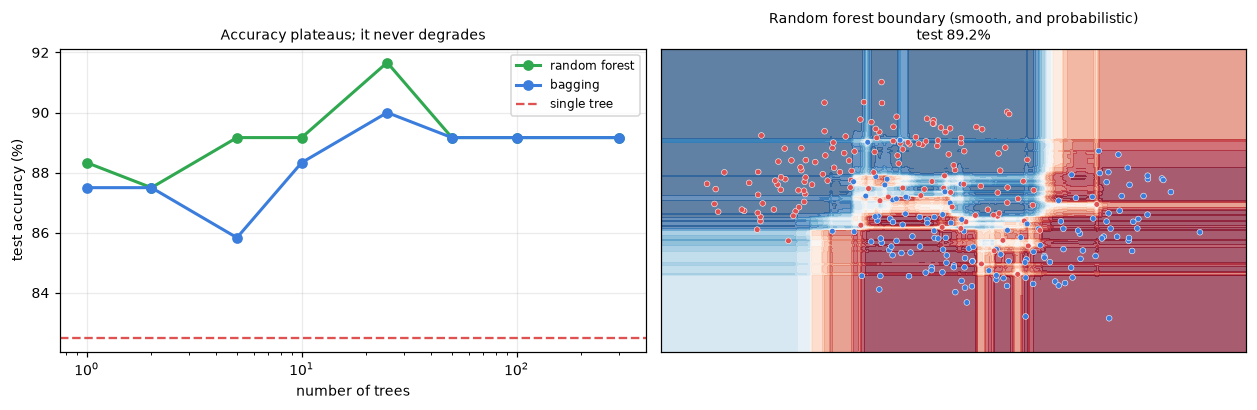

Compare this boundary with the single tree in Part 1: still built from
rectangles, but averaging hundreds of them produces something smooth.

n_estimators is therefore NOT a parameter you tune for accuracy - you set it
as high as your compute budget allows. This is unique to bagging-type methods;
in boosting, more estimators CAN overfit (Part 5).


In [15]:
# more trees never hurts - the practical consequence of the variance formula
ns = [1, 2, 5, 10, 25, 50, 100, 300]
rf_curve, bag_curve = [], []
for n_est in ns:
    rf_curve.append(RandomForestClassifier(n_estimators=n_est, random_state=0)
                    .fit(Xm_tr, ym_tr).score(Xm_te, ym_te))
    bag_curve.append(BaggingClassifier(n_estimators=n_est, random_state=0)
                     .fit(Xm_tr, ym_tr).score(Xm_te, ym_te))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
axes[0].plot(ns, np.array(rf_curve) * 100, "o-", color=GREEN, lw=2, label="random forest")
axes[0].plot(ns, np.array(bag_curve) * 100, "o-", color=BLUE, lw=2, label="bagging")
axes[0].axhline(single.score(Xm_te, ym_te) * 100, ls="--", color=RED, label="single tree")
axes[0].set_xscale("log"); axes[0].set_xlabel("number of trees"); axes[0].set_ylabel("test accuracy (%)")
axes[0].legend(fontsize=8); axes[0].set_title("Accuracy plateaus; it never degrades", fontsize=9)

rf_final = RandomForestClassifier(n_estimators=300, random_state=0).fit(Xm_tr, ym_tr)
plot_boundary(rf_final, Xm_tr, ym_tr, ax=axes[1], proba=True,
              title=f"Random forest boundary (smooth, and probabilistic)\n"
                    f"test {rf_final.score(Xm_te, ym_te)*100:.1f}%")
plt.tight_layout(); plt.show()

print("Compare this boundary with the single tree in Part 1: still built from")
print("rectangles, but averaging hundreds of them produces something smooth.")
print("\nn_estimators is therefore NOT a parameter you tune for accuracy - you set it")
print("as high as your compute budget allows. This is unique to bagging-type methods;")
print("in boosting, more estimators CAN overfit (Part 5).")

### Extremely Randomized Trees

One more step in the same direction: `ExtraTreesClassifier` picks the split **threshold** at random too, instead of searching for the best one. Even more bias per tree, even less correlation, and much faster to fit (no threshold search). Often as good as a random forest, and worth trying whenever you use one.

---

# Part 4 — Boosting

Bagging builds many models **in parallel** and averages away their variance. Boosting does something structurally different: it builds models **in sequence**, each one trained to fix the mistakes of the ones before it.

| | Bagging / Random Forest | Boosting |
|---|---|---|
| Models are built | in parallel, independently | sequentially, each depending on the last |
| Base learner | deep trees (low bias, high variance) | shallow trees / stumps (high bias, low variance) |
| Reduces | **variance** | **bias** |
| More estimators | never hurts | **can overfit** |
| Parallelizable | trivially | not across estimators |
| Tuning | easy, forgiving | needs care (learning rate, depth, number) |

The base learner in boosting is deliberately **weak** — often a depth-1 stump. The theory of boosting says that any learner slightly better than chance can be combined into an arbitrarily strong one.

## 4.1 AdaBoost

The original (Freund & Schapire, 1997). It keeps a **weight** on every training sample:

1. start with equal weights $w_i = 1/m$,
2. fit a weak learner on the weighted data,
3. compute its weighted error $\varepsilon$, and give it a voice $\alpha = \frac{1}{2}\ln\frac{1-\varepsilon}{\varepsilon}$,
4. **increase** the weights of the samples it got wrong, decrease the rest, renormalize,
5. repeat. Predict by the $\alpha$-weighted vote.

Read step 3: a learner with $\varepsilon \to 0$ gets a huge $\alpha$; one at $\varepsilon = 0.5$ (chance) gets $\alpha = 0$ and is ignored; one worse than chance gets a *negative* $\alpha$ and is used in reverse. Step 4 is the heart of it — **the next learner is forced to concentrate on what is still hard.**

In [16]:
class AdaBoost:
    """AdaBoost.M1 with decision stumps. Labels must be -1 / +1."""

    def __init__(self, n_estimators=50, max_depth=1):
        self.n_estimators, self.max_depth = n_estimators, max_depth

    def fit(self, X, y):
        m = len(y)
        w = np.full(m, 1 / m)                              # 1. equal weights
        self.trees_, self.alphas_, self.weight_history_ = [], [], []

        for t in range(self.n_estimators):
            stump = DecisionTreeClassifier(max_depth=self.max_depth, random_state=0)
            stump.fit(X, y, sample_weight=w)               # 2. fit on the weighted data
            pred = stump.predict(X)

            err = np.sum(w[pred != y]) / np.sum(w)         # 3. weighted error
            err = np.clip(err, 1e-10, 1 - 1e-10)
            alpha = 0.5 * np.log((1 - err) / err)          #    its voice

            self.weight_history_.append(w.copy())
            w = w * np.exp(-alpha * y * pred)              # 4. reweight: wrong -> heavier
            w /= w.sum()

            self.trees_.append(stump); self.alphas_.append(alpha)
        return self

    def decision_function(self, X, n_use=None):
        n_use = n_use or len(self.trees_)
        return sum(a * t.predict(X) for a, t in
                   zip(self.alphas_[:n_use], self.trees_[:n_use]))

    def predict(self, X, n_use=None):
        return np.sign(self.decision_function(X, n_use))

    def score(self, X, y, n_use=None):
        return float(np.mean(self.predict(X, n_use) == y))


y_pm = np.where(ym_tr == 0, -1, 1)
y_pm_te = np.where(ym_te == 0, -1, 1)
ada = AdaBoost(n_estimators=200).fit(Xm_tr, y_pm)

from sklearn.ensemble import AdaBoostClassifier
skl_ada = AdaBoostClassifier(n_estimators=200, random_state=0).fit(Xm_tr, y_pm)
print(f"ours   : test {ada.score(Xm_te, y_pm_te)*100:.2f}%")
print(f"sklearn: test {skl_ada.score(Xm_te, y_pm_te)*100:.2f}%")
print(f"\nfirst 5 alphas: {np.round(ada.alphas_[:5], 3)}")
print("Decreasing, as expected: the early stumps have the easiest job.")

ours   : test 89.17%
sklearn: test 89.17%

first 5 alphas: [0.727 0.363 0.689 0.364 0.415]
Decreasing, as expected: the early stumps have the easiest job.


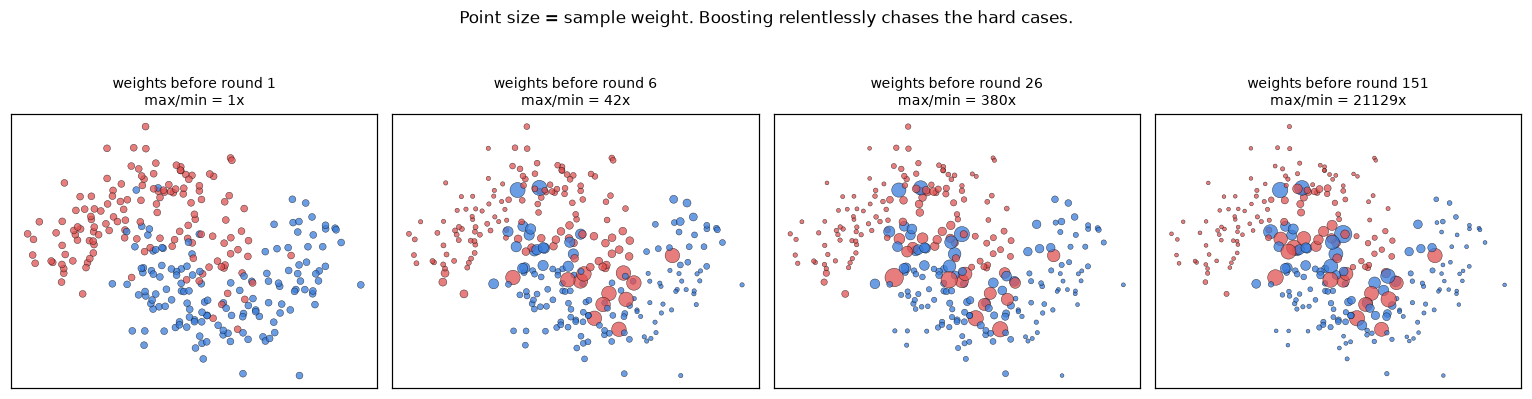

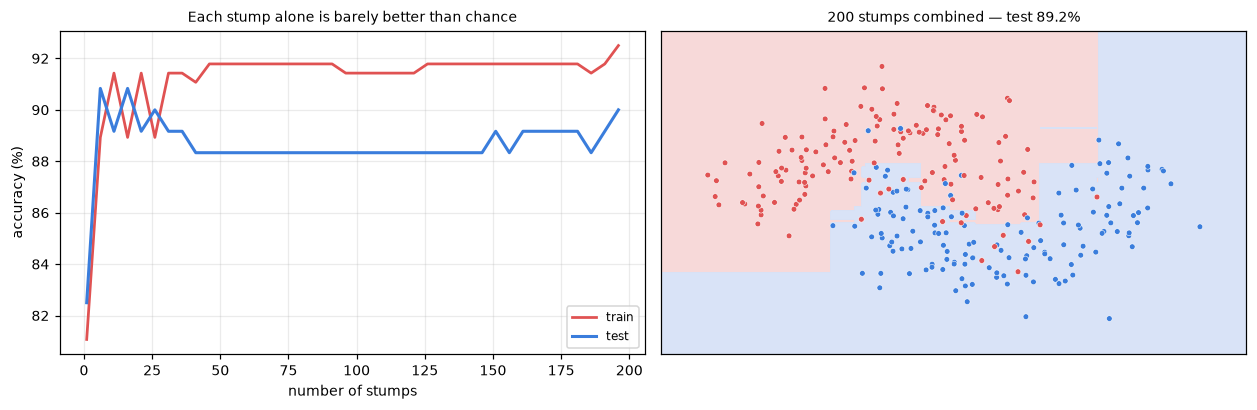

accuracy of the FIRST stump alone: 81.1%
accuracy of 200 of them together : 89.2%


In [17]:
# watch the sample weights concentrate on the hard points
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))
for ax, t in zip(axes, [0, 5, 25, 150]):
    w = ada.weight_history_[t]
    ax.scatter(Xm_tr[:, 0], Xm_tr[:, 1], c=ym_tr, cmap=CMAP_PTS,
               s=6 + 4000 * w, alpha=0.75, edgecolor="k", linewidth=0.3)
    ax.set_title(f"weights before round {t+1}\nmax/min = {w.max()/w.min():.0f}x", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Point size = sample weight. Boosting relentlessly chases the hard cases.", y=1.05)
plt.tight_layout(); plt.show()

# and how the ensemble accuracy builds up
ns = np.arange(1, 201, 5)
tr = [ada.score(Xm_tr, y_pm, n_use=n) for n in ns]
te = [ada.score(Xm_te, y_pm_te, n_use=n) for n in ns]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
axes[0].plot(ns, np.array(tr) * 100, color=RED, lw=1.8, label="train")
axes[0].plot(ns, np.array(te) * 100, color=BLUE, lw=2, label="test")
axes[0].set_xlabel("number of stumps"); axes[0].set_ylabel("accuracy (%)")
axes[0].legend(fontsize=8); axes[0].set_title("Each stump alone is barely better than chance", fontsize=9)

class _W:
    def __init__(s, a): s.a = a
    def predict(s, X): return (s.a.predict(X) > 0).astype(int)
plot_boundary(_W(ada), Xm_tr, ym_tr, ax=axes[1],
              title=f"200 stumps combined — test {ada.score(Xm_te, y_pm_te)*100:.1f}%")
plt.tight_layout(); plt.show()

print(f"accuracy of the FIRST stump alone: {ada.trees_[0].score(Xm_tr, y_pm)*100:.1f}%")
print(f"accuracy of 200 of them together : {ada.score(Xm_te, y_pm_te)*100:.1f}%")

## 4.2 Gradient boosting

Gradient boosting (Friedman, 2001) generalizes the idea and is what actually dominates practice today. Instead of reweighting samples, each new tree is fitted to the **residuals** — what the ensemble has got wrong so far:

1. start with a constant prediction $F_0(\mathbf{x}) = \bar{y}$,
2. compute the residuals $r_i = y_i - F_{t-1}(\mathbf{x}_i)$,
3. fit a small tree $h_t$ to predict those residuals,
4. update $F_t = F_{t-1} + \eta\, h_t$,
5. repeat.

$\eta$ is the **learning rate** (shrinkage). Taking small steps and using more of them almost always generalizes better than taking large ones — the same trade-off as in gradient descent, and the single most important hyperparameter here.

The name comes from the general version: the residual $y - F$ is exactly the negative gradient of the squared-error loss with respect to the prediction. Swap in a different loss and you get its own gradient — log-loss for classification, absolute error for robust regression — so the same machinery covers every task. **Gradient boosting is gradient descent, performed in function space, one tree per step.**

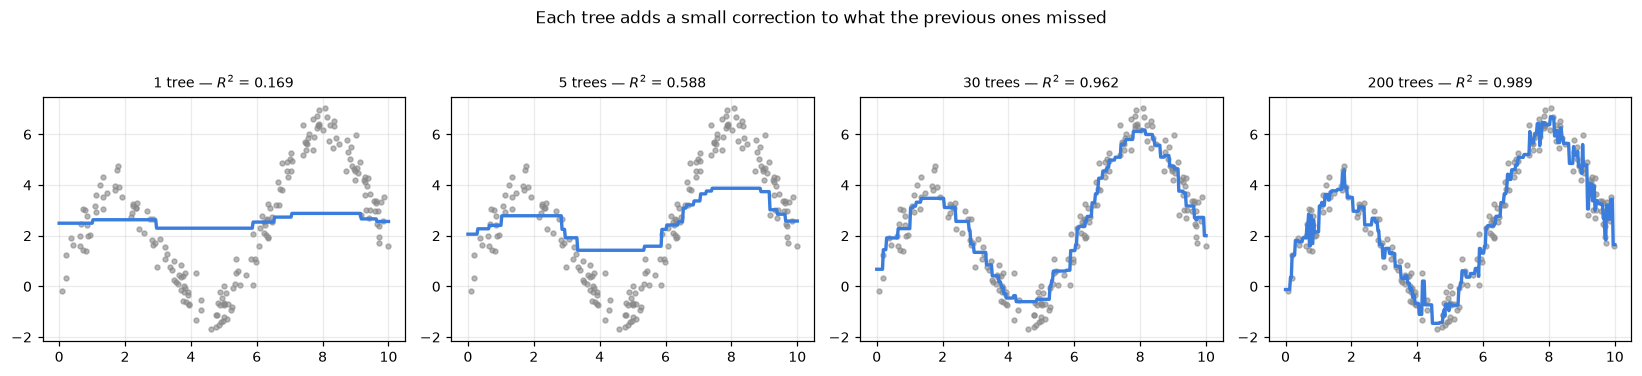

ours   : R2 = 0.9890
sklearn: R2 = 0.9890


In [18]:
class GradientBoostingRegressorScratch:
    """Gradient boosting with squared error: each tree fits the current residuals."""

    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3):
        self.n_estimators, self.lr, self.max_depth = n_estimators, learning_rate, max_depth

    def fit(self, X, y):
        self.F0_ = float(np.mean(y))                      # 1. constant starting model
        F = np.full(len(y), self.F0_)
        self.trees_, self.train_loss_ = [], []
        for _ in range(self.n_estimators):
            residual = y - F                              # 2. what we still get wrong
            tree = DecisionTreeRegressor(max_depth=self.max_depth, random_state=0)
            tree.fit(X, residual)                         # 3. fit a tree to the residuals
            F = F + self.lr * tree.predict(X)             # 4. take a small step
            self.trees_.append(tree)
            self.train_loss_.append(float(np.mean((y - F) ** 2)))
        return self

    def predict(self, X, n_use=None):
        n_use = n_use or len(self.trees_)
        F = np.full(len(X), self.F0_)
        for tree in self.trees_[:n_use]:
            F += self.lr * tree.predict(X)
        return F

    def score(self, X, y, n_use=None):
        p = self.predict(X, n_use)
        return 1 - ((y - p) ** 2).sum() / ((y - np.mean(y)) ** 2).sum()


rng = np.random.default_rng(4)
xg = np.sort(rng.uniform(0, 10, 200))
yg = np.sin(xg) * 3 + 0.4 * xg + rng.normal(0, 0.5, 200)
Xg = xg.reshape(-1, 1)
grid = np.linspace(0, 10, 400).reshape(-1, 1)

gb = GradientBoostingRegressorScratch(n_estimators=200, learning_rate=0.1, max_depth=3).fit(Xg, yg)

fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
for ax, n in zip(axes, [1, 5, 30, 200]):
    ax.scatter(xg, yg, s=10, color=GREY, alpha=0.6)
    ax.plot(grid, gb.predict(grid, n_use=n), color=BLUE, lw=2.2)
    ax.set_title(f"{n} tree{'s' if n > 1 else ''} — $R^2$ = {gb.score(Xg, yg, n_use=n):.3f}",
                 fontsize=9)
plt.suptitle("Each tree adds a small correction to what the previous ones missed", y=1.05)
plt.tight_layout(); plt.show()

from sklearn.ensemble import GradientBoostingRegressor
skl = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3,
                                random_state=0).fit(Xg, yg)
print(f"ours   : R2 = {gb.score(Xg, yg):.4f}")
print(f"sklearn: R2 = {skl.score(Xg, yg):.4f}")

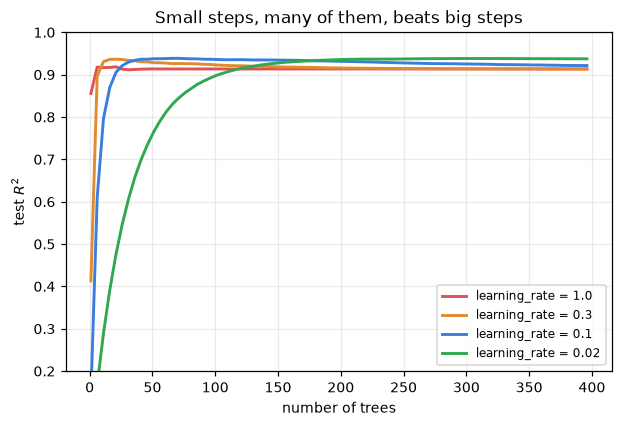

Read the red curve: with learning_rate = 1.0 the model peaks early and then
DEGRADES. That is boosting overfitting - something bagging never does.

The practical recipe:
  1. fix a small learning rate (0.05-0.1)
  2. set n_estimators high
  3. use EARLY STOPPING on a validation set to pick where to stop
Smaller learning rate = more trees needed = slower, but usually better.


In [19]:
# the learning rate / n_estimators trade-off - the core tuning decision in boosting
xg_tr, xg_te, yg_tr, yg_te = train_test_split(Xg, yg, test_size=0.35, random_state=0)

plt.figure(figsize=(6.4, 4))
ns = np.arange(1, 401, 5)
for lr, col in [(1.0, RED), (0.3, ORANGE), (0.1, BLUE), (0.02, GREEN)]:
    g = GradientBoostingRegressorScratch(n_estimators=400, learning_rate=lr, max_depth=3)
    g.fit(xg_tr, yg_tr)
    plt.plot(ns, [g.score(xg_te, yg_te, n_use=n) for n in ns], color=col, lw=1.9,
             label=f"learning_rate = {lr}")
plt.xlabel("number of trees"); plt.ylabel("test $R^2$"); plt.ylim(0.2, 1.0)
plt.legend(fontsize=8); plt.title("Small steps, many of them, beats big steps")
plt.show()

print("Read the red curve: with learning_rate = 1.0 the model peaks early and then")
print("DEGRADES. That is boosting overfitting - something bagging never does.")
print("\nThe practical recipe:")
print("  1. fix a small learning rate (0.05-0.1)")
print("  2. set n_estimators high")
print("  3. use EARLY STOPPING on a validation set to pick where to stop")
print("Smaller learning rate = more trees needed = slower, but usually better.")

---

# Part 5 — The modern libraries

## 5.1 Which implementation

| Library / class | Notes |
|---|---|
| `GradientBoostingClassifier` | scikit-learn's classic implementation. Correct, but slow on large data |
| **`HistGradientBoostingClassifier`** | scikit-learn's modern one: bins features into 256 histograms, handles missing values and categorical features natively. **Use this one.** Comparable to LightGBM |
| **XGBoost** | the one that made boosting famous. Regularized objective, second-order gradients, excellent GPU support |
| **LightGBM** | leaf-wise growth instead of level-wise; usually the fastest on large data |
| **CatBoost** | ordered boosting and outstanding native handling of categorical features |

All four are close in accuracy when properly tuned. Choose on engineering grounds — speed, categorical handling, GPU — not on expected accuracy.

## 5.2 The hyperparameters that actually matter

**Random forest** (very forgiving — the defaults are usually near-optimal):

| Parameter | Advice |
|---|---|
| `n_estimators` | as many as you can afford. Never hurts |
| `max_features` | `sqrt` for classification, ~`0.3` for regression. The main tuning knob |
| `max_depth` / `min_samples_leaf` | usually leave unlimited; raise `min_samples_leaf` on noisy data |

**Gradient boosting** (needs real tuning):

| Parameter | Advice |
|---|---|
| `learning_rate` | 0.05–0.1. The most important |
| `n_estimators` | high, combined with **early stopping** |
| `max_depth` / `max_leaf_nodes` | 3–8. Deeper = more interactions and more overfitting |
| `subsample` | 0.5–0.8 adds bagging on top ("stochastic gradient boosting") — usually helps |
| `min_samples_leaf` | raise on noisy data |
| `reg_lambda`, `reg_alpha` | L2/L1 on the leaf values (XGBoost/LightGBM) |

In [20]:
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              HistGradientBoostingClassifier, AdaBoostClassifier,
                              GradientBoostingClassifier, VotingClassifier, StackingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

bc = load_breast_cancer()
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(bc.data, bc.target, test_size=0.25,
                                              random_state=0, stratify=bc.target)

models = {
    "single tree (depth 4)": DecisionTreeClassifier(max_depth=4, random_state=0),
    "single tree (unpruned)": DecisionTreeClassifier(random_state=0),
    "bagging (100)": BaggingClassifier(n_estimators=100, random_state=0),
    "random forest (300)": RandomForestClassifier(n_estimators=300, random_state=0),
    "extra trees (300)": ExtraTreesClassifier(n_estimators=300, random_state=0),
    "AdaBoost (200 stumps)": AdaBoostClassifier(n_estimators=200, random_state=0),
    "gradient boosting": GradientBoostingClassifier(random_state=0),
    "hist gradient boosting": HistGradientBoostingClassifier(random_state=0),
    "logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
}

print(f"{'model':<28} {'fit time':>10} {'CV accuracy':>13} {'test accuracy':>15}")
print("-" * 70)
results = {}
for name, mdl in models.items():
    t0 = time.time(); mdl.fit(Xb_tr, yb_tr); dt = time.time() - t0
    cv = cross_val_score(mdl, Xb_tr, yb_tr, cv=5).mean()
    results[name] = mdl.score(Xb_te, yb_te)
    print(f"{name:<28} {dt:>9.2f}s {cv*100:>12.2f}% {results[name]*100:>14.2f}%")

model                          fit time   CV accuracy   test accuracy
----------------------------------------------------------------------
single tree (depth 4)             0.00s        92.25%          90.91%
single tree (unpruned)            0.00s        92.48%          90.21%
bagging (100)                     0.13s        96.01%          93.71%
random forest (300)               0.15s        95.55%          94.41%
extra trees (300)                 0.09s        97.19%          94.41%
AdaBoost (200 stumps)             0.16s        95.77%          94.41%
gradient boosting                 0.12s        96.48%          95.80%
hist gradient boosting            0.19s        96.95%          93.71%
logistic regression               0.00s        97.42%          95.80%


## 5.3 Voting and stacking

Two ways to combine models that are **not** all trees.

**Voting** — average the predictions of several different model families. Use `voting="soft"` (average the probabilities) rather than `"hard"` (majority vote) whenever the models are calibrated; soft voting uses the confidence, not just the decision.

**Stacking** — train a **meta-model** on the base models' out-of-fold predictions, so it can learn *when to trust which*. More powerful and more dangerous: the out-of-fold construction is essential, or the meta-model sees predictions the base models made on their own training data and everything leaks.

Both usually give a small gain over the best single model. They are the standard final move in competitions and are rarely worth the complexity in production.

In [21]:
base = [
    ("rf", RandomForestClassifier(n_estimators=200, random_state=0)),
    ("gb", HistGradientBoostingClassifier(random_state=0)),
    ("lr", make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))),
]

vote = VotingClassifier(base, voting="soft").fit(Xb_tr, yb_tr)
stack = StackingClassifier(base, final_estimator=LogisticRegression(max_iter=5000),
                           cv=5).fit(Xb_tr, yb_tr)   # cv=5 -> out-of-fold predictions

print(f"{'model':<34} {'test accuracy':>14}")
print("-" * 50)
for n in ["random forest (300)", "hist gradient boosting", "logistic regression"]:
    print(f"{n:<34} {results[n]*100:>13.2f}%")
print(f"{'soft voting of the three':<34} {vote.score(Xb_te, yb_te)*100:>13.2f}%")
print(f"{'stacking (logistic meta-model)':<34} {stack.score(Xb_te, yb_te)*100:>13.2f}%")

print("\nThe meta-model's coefficients show how much it trusts each base model:")
for (n, _), c in zip(base, stack.final_estimator_.coef_[0]):
    print(f"   {n}: {c:+.3f}")
print("\nEnsembles of DIFFERENT model families help most when the members make")
print("DIFFERENT mistakes - the decorrelation principle from Part 3, one level up.")

model                               test accuracy
--------------------------------------------------
random forest (300)                        94.41%
hist gradient boosting                     93.71%
logistic regression                        95.80%
soft voting of the three                   95.80%
stacking (logistic meta-model)             95.80%

The meta-model's coefficients show how much it trusts each base model:
   rf: +2.548
   gb: +2.253
   lr: +3.439

Ensembles of DIFFERENT model families help most when the members make
DIFFERENT mistakes - the decorrelation principle from Part 3, one level up.


---

# Part 6 — Six challenge problems

## Challenge 1 — Feature importance that lies

**The task.** Random forests report `feature_importances_` for free, and people put them in slide decks. Two well-known biases make the impurity-based version untrustworthy:

1. **High-cardinality bias.** A feature with many distinct values (an ID, a continuous variable) offers more candidate splits, so it wins more of them by chance.
2. **Correlated features split the credit.** Two near-identical informative features each get about half the importance, so both look half as useful as they are.

We build a dataset where we know the truth exactly, and watch both failures happen.

feature                          truth   impurity importance   permutation
----------------------------------------------------------------------------
useful                   strong signal                 0.391         0.157
useful_copy      duplicate of 'useful'                 0.380         0.151
weak                       weak signal                 0.135         0.040
random_id                 NONE (an ID)                 0.085        -0.009
binary_noise       NONE (binary noise)                 0.009        -0.001


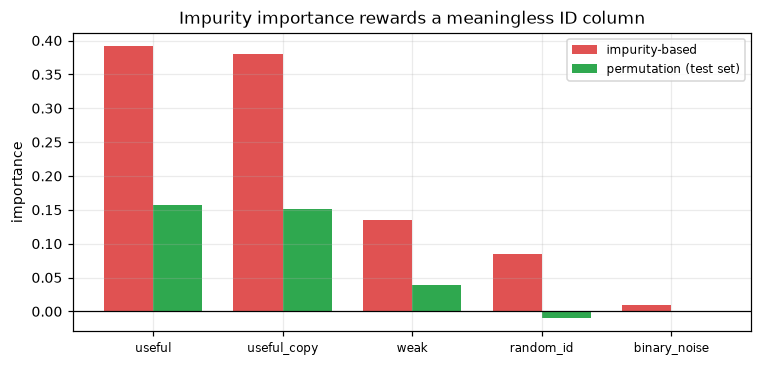


DIAGNOSIS: 'random_id' contains NO information whatsoever, yet impurity
importance awards it a solid 8-9% of the total - more than a third of what
the genuinely weak feature gets. A continuous ID offers thousands of candidate
thresholds, so a tree can always find one that helps a little on TRAINING data.
Note also that 'binary_noise' - equally useless, but with only 2 values -
scores near zero. The bias is about CARDINALITY, not about being informative.

FIX: use PERMUTATION IMPORTANCE, computed on HELD-OUT data. Shuffle one
column and measure how much the score drops. A useless column costs nothing
when shuffled, so it scores ~0 - which is exactly what we see.

CAVEAT: permutation importance also splits credit between correlated features
(note 'useful' and 'useful_copy'), because shuffling one leaves the other
intact. For correlated groups, permute the whole group together.


In [22]:
from sklearn.inspection import permutation_importance

rng = np.random.default_rng(0)
n = 2000
useful = rng.normal(size=n)
useful_copy = useful + rng.normal(0, 0.05, n)      # a near-duplicate of 'useful'
weak = rng.normal(size=n)
random_id = rng.permutation(n).astype(float)       # a pure ID: zero information
binary_noise = rng.integers(0, 2, n).astype(float) # noise, but only 2 distinct values

Xf = np.column_stack([useful, useful_copy, weak, random_id, binary_noise])
names = ["useful", "useful_copy", "weak", "random_id", "binary_noise"]
yf = (1.5 * useful + 0.4 * weak + rng.normal(0, 0.6, n) > 0).astype(int)

Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(Xf, yf, test_size=0.3, random_state=0)
rf = RandomForestClassifier(n_estimators=300, random_state=0).fit(Xf_tr, yf_tr)

perm = permutation_importance(rf, Xf_te, yf_te, n_repeats=20, random_state=0)

print(f"{'feature':<15} {'truth':>22} {'impurity importance':>21} {'permutation':>13}")
print("-" * 76)
truth = ["strong signal", "duplicate of 'useful'", "weak signal",
         "NONE (an ID)", "NONE (binary noise)"]
for nm, t, imp, pm in zip(names, truth, rf.feature_importances_, perm.importances_mean):
    print(f"{nm:<15} {t:>22} {imp:>21.3f} {pm:>13.3f}")

fig, ax = plt.subplots(figsize=(7, 3.4))
w = 0.38
ax.bar(np.arange(5) - w/2, rf.feature_importances_, w, color=RED, label="impurity-based")
ax.bar(np.arange(5) + w/2, perm.importances_mean, w, color=GREEN, label="permutation (test set)")
ax.set_xticks(range(5), names, fontsize=8); ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("importance"); ax.legend(fontsize=8)
ax.set_title("Impurity importance rewards a meaningless ID column")
plt.tight_layout(); plt.show()

print("\nDIAGNOSIS: 'random_id' contains NO information whatsoever, yet impurity")
print("importance awards it a solid 8-9% of the total - more than a third of what")
print("the genuinely weak feature gets. A continuous ID offers thousands of candidate")
print("thresholds, so a tree can always find one that helps a little on TRAINING data.")
print("Note also that 'binary_noise' - equally useless, but with only 2 values -")
print("scores near zero. The bias is about CARDINALITY, not about being informative.")
print("\nFIX: use PERMUTATION IMPORTANCE, computed on HELD-OUT data. Shuffle one")
print("column and measure how much the score drops. A useless column costs nothing")
print("when shuffled, so it scores ~0 - which is exactly what we see.")
print("\nCAVEAT: permutation importance also splits credit between correlated features")
print("(note 'useful' and 'useful_copy'), because shuffling one leaves the other")
print("intact. For correlated groups, permute the whole group together.")

## Challenge 2 — Boosting overfits; bagging does not

**The task.** Noisy labels. We keep adding estimators to both a random forest and a gradient booster and watch what happens. This is the most important behavioural difference between the two families.

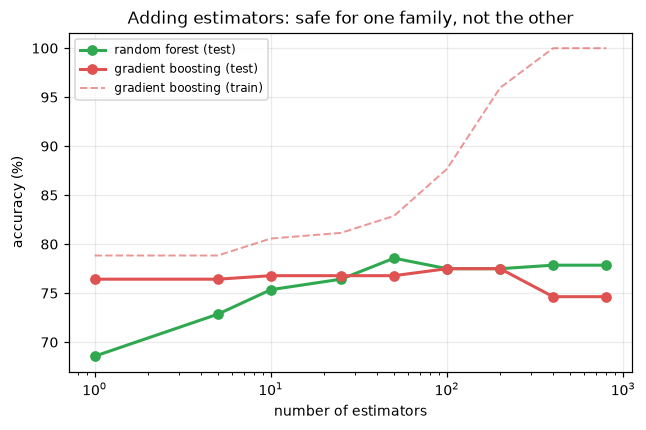

random forest    : peak 78.6%, final 77.9%  (no decay)
gradient boosting: peak 77.5% at 100 trees, final 74.6%

with early stopping: stopped at 62 iterations, test 76.4%

DIAGNOSIS: boosting fits residuals, and with noisy labels the residuals ARE
the noise - so it eventually memorizes it. Random forests average independent
models, so extra members can only reduce variance.

FIXES: lower learning_rate, shallower trees, subsample < 1, and above all
EARLY STOPPING. On noisy data a random forest is often the safer default.


In [23]:
Xn, yn = make_moons(n_samples=800, noise=0.38, random_state=1)
rng = np.random.default_rng(2)
flip = rng.random(len(yn)) < 0.12                            # 12% corrupted labels
yn_noisy = np.where(flip, 1 - yn, yn)
Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(Xn, yn_noisy, test_size=0.35, random_state=0)

ns = [1, 5, 10, 25, 50, 100, 200, 400, 800]
rf_te, gb_te, gb_tr = [], [], []
for n_est in ns:
    rf_te.append(RandomForestClassifier(n_estimators=n_est, random_state=0)
                 .fit(Xn_tr, yn_tr).score(Xn_te, yn_te))
    g = GradientBoostingClassifier(n_estimators=n_est, learning_rate=0.1,
                                   max_depth=3, random_state=0).fit(Xn_tr, yn_tr)
    gb_te.append(g.score(Xn_te, yn_te)); gb_tr.append(g.score(Xn_tr, yn_tr))

plt.figure(figsize=(6.6, 4))
plt.plot(ns, np.array(rf_te) * 100, "o-", color=GREEN, lw=2, label="random forest (test)")
plt.plot(ns, np.array(gb_te) * 100, "o-", color=RED, lw=2, label="gradient boosting (test)")
plt.plot(ns, np.array(gb_tr) * 100, "--", color=RED, lw=1.3, alpha=0.6,
         label="gradient boosting (train)")
plt.xscale("log"); plt.xlabel("number of estimators"); plt.ylabel("accuracy (%)")
plt.legend(fontsize=8); plt.title("Adding estimators: safe for one family, not the other")
plt.show()

print(f"random forest    : peak {max(rf_te)*100:.1f}%, final {rf_te[-1]*100:.1f}%  (no decay)")
print(f"gradient boosting: peak {max(gb_te)*100:.1f}% at {ns[int(np.argmax(gb_te))]} trees, "
      f"final {gb_te[-1]*100:.1f}%")

# the fix: early stopping on a validation set
from sklearn.ensemble import HistGradientBoostingClassifier
es = HistGradientBoostingClassifier(learning_rate=0.05, max_iter=1000,
                                    early_stopping=True, validation_fraction=0.2,
                                    n_iter_no_change=20, random_state=0).fit(Xn_tr, yn_tr)
print(f"\nwith early stopping: stopped at {es.n_iter_} iterations, "
      f"test {es.score(Xn_te, yn_te)*100:.1f}%")

print("\nDIAGNOSIS: boosting fits residuals, and with noisy labels the residuals ARE")
print("the noise - so it eventually memorizes it. Random forests average independent")
print("models, so extra members can only reduce variance.")
print("\nFIXES: lower learning_rate, shallower trees, subsample < 1, and above all")
print("EARLY STOPPING. On noisy data a random forest is often the safer default.")

## Challenge 3 — Trees cannot extrapolate

**The task.** A time series with a clear upward trend. We train on the first 70% and predict the rest — a completely standard forecasting setup, and one where a tree model fails in a way that is easy to miss if you only look at cross-validated scores computed on shuffled data.

random forest        in-sample R2  0.997   FUTURE R2  -0.461
gradient boosting    in-sample R2  0.996   FUTURE R2  -0.016
linear regression    in-sample R2  0.986   FUTURE R2   0.953


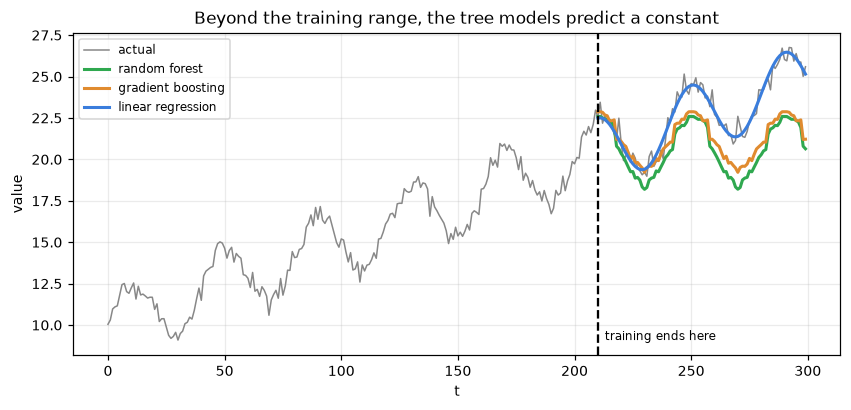


DIAGNOSIS: a tree predicts the mean of a leaf, and every future point falls
into the same right-most leaf. The seasonal wiggle survives (those features
stay in range) but the TREND is lost completely.

FIXES:
  - DETREND first: fit a linear model to the trend, boost the residuals
  - or engineer features that stay in range (differences, ratios, lags)
  - or use a model class that extrapolates (linear, or a linear-leaf GBM)
Note that a randomly shuffled cross-validation would have MISSED this entirely.


In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge

t_all = np.arange(300)
trend = 0.05 * t_all
season = 2.0 * np.sin(2 * np.pi * t_all / 40)
series = 10 + trend + season + np.random.default_rng(0).normal(0, 0.4, 300)

split = 210
X_t = np.column_stack([t_all, np.sin(2 * np.pi * t_all / 40), np.cos(2 * np.pi * t_all / 40)])
Xt_tr, Xt_te = X_t[:split], X_t[split:]
yt_tr, yt_te = series[:split], series[split:]

from sklearn.metrics import r2_score
preds = {}
for name, mdl in [("random forest", RandomForestRegressor(n_estimators=300, random_state=0)),
                  ("gradient boosting", GradientBoostingRegressor(random_state=0)),
                  ("linear regression", LinearRegression())]:
    mdl.fit(Xt_tr, yt_tr)
    preds[name] = mdl.predict(X_t)
    print(f"{name:<20} in-sample R2 {mdl.score(Xt_tr, yt_tr):>6.3f}   "
          f"FUTURE R2 {r2_score(yt_te, mdl.predict(Xt_te)):>7.3f}")

plt.figure(figsize=(9, 3.8))
plt.plot(t_all, series, color=GREY, lw=1, label="actual")
for (name, p), col in zip(preds.items(), [GREEN, ORANGE, BLUE]):
    plt.plot(t_all[split:], p[split:], color=col, lw=2, label=name)
plt.axvline(split, ls="--", color="k")
plt.text(split + 3, series.min(), "training ends here", fontsize=8)
plt.xlabel("t"); plt.ylabel("value"); plt.legend(fontsize=8)
plt.title("Beyond the training range, the tree models predict a constant")
plt.show()

print("\nDIAGNOSIS: a tree predicts the mean of a leaf, and every future point falls")
print("into the same right-most leaf. The seasonal wiggle survives (those features")
print("stay in range) but the TREND is lost completely.")
print("\nFIXES:")
print("  - DETREND first: fit a linear model to the trend, boost the residuals")
print("  - or engineer features that stay in range (differences, ratios, lags)")
print("  - or use a model class that extrapolates (linear, or a linear-leaf GBM)")
print("Note that a randomly shuffled cross-validation would have MISSED this entirely.")

random forest, future R2 : -0.461
hybrid linear+GBM, future: 0.930


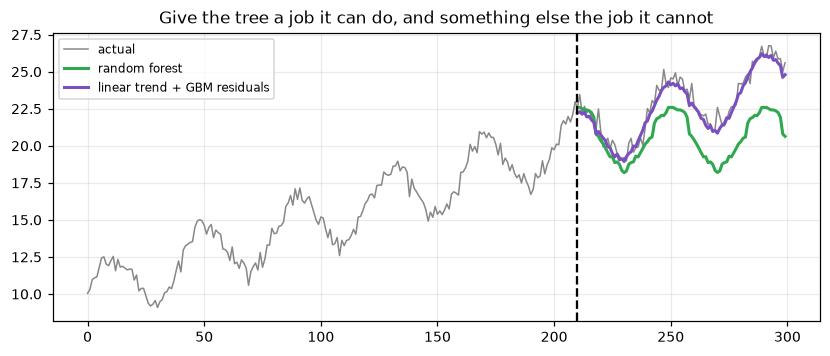

In [25]:
# the fix: let a linear model carry the trend and a tree model carry the rest
lin = LinearRegression().fit(Xt_tr[:, :1], yt_tr)          # trend only
resid_tr = yt_tr - lin.predict(Xt_tr[:, :1])
gb_resid = GradientBoostingRegressor(random_state=0).fit(Xt_tr[:, 1:], resid_tr)

hybrid = lin.predict(X_t[:, :1]) + gb_resid.predict(X_t[:, 1:])
print(f"random forest, future R2 : {r2_score(yt_te, preds['random forest'][split:]):.3f}")
print(f"hybrid linear+GBM, future: {r2_score(yt_te, hybrid[split:]):.3f}")

plt.figure(figsize=(9, 3.4))
plt.plot(t_all, series, color=GREY, lw=1, label="actual")
plt.plot(t_all[split:], preds["random forest"][split:], color=GREEN, lw=2, label="random forest")
plt.plot(t_all[split:], hybrid[split:], color=PURPLE, lw=2, label="linear trend + GBM residuals")
plt.axvline(split, ls="--", color="k"); plt.legend(fontsize=8)
plt.title("Give the tree a job it can do, and something else the job it cannot")
plt.show()

## Challenge 4 — High-cardinality categorical features

**The task.** A feature with 200 categories — a product code, a postcode, a user ID. One-hot encoding it for a tree is a common and costly mistake: each binary column can only ever make one very unbalanced split, so the tree needs enormous depth to use the feature at all.

In [26]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

rng = np.random.default_rng(5)
n_cat, n = 200, 6000
cat_effect = rng.normal(0, 2.5, n_cat)
cat = rng.integers(0, n_cat, n)
x_num = rng.normal(size=n)
target = (0.8 * x_num + cat_effect[cat] + rng.normal(0, 1.0, n) > 0).astype(int)

idx_tr, idx_te = train_test_split(np.arange(n), test_size=0.3, random_state=0)

print(f"{'encoding':<44} {'features':>9} {'fit time':>9} {'test acc':>10}")
print("-" * 76)

# 1. one-hot: 500 extra columns
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore").fit(cat[idx_tr, None])
A_tr = np.c_[x_num[idx_tr], ohe.transform(cat[idx_tr, None])]
A_te = np.c_[x_num[idx_te], ohe.transform(cat[idx_te, None])]
t0 = time.time(); m1 = RandomForestClassifier(n_estimators=200, random_state=0).fit(A_tr, target[idx_tr])
print(f"{'one-hot (200 columns)':<44} {A_tr.shape[1]:>9} {time.time()-t0:>8.2f}s "
      f"{m1.score(A_te, target[idx_te])*100:>9.1f}%")

# 2. ordinal: the tree treats the code as a number. Meaningless order, but it can still
#    isolate ranges of codes, and with enough depth that is surprisingly effective.
B_tr = np.c_[x_num[idx_tr], cat[idx_tr]]
B_te = np.c_[x_num[idx_te], cat[idx_te]]
t0 = time.time(); m2 = RandomForestClassifier(n_estimators=200, random_state=0).fit(B_tr, target[idx_tr])
print(f"{'ordinal (raw code as a number)':<44} {B_tr.shape[1]:>9} {time.time()-t0:>8.2f}s "
      f"{m2.score(B_te, target[idx_te])*100:>9.1f}%")

# 3. native categorical support
t0 = time.time()
m3 = HistGradientBoostingClassifier(categorical_features=[1], max_iter=300,
                                    random_state=0).fit(B_tr, target[idx_tr])
print(f"{'HistGradientBoosting, native categorical':<44} {B_tr.shape[1]:>9} "
      f"{time.time()-t0:>8.2f}s {m3.score(B_te, target[idx_te])*100:>9.1f}%")

# 4. out-of-fold target encoding
from sklearn.preprocessing import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
enc = ColumnTransformer([("te", TargetEncoder(target_type="binary"), [1])],
                        remainder="passthrough")
t0 = time.time()
m4 = Pipeline([("enc", enc), ("rf", RandomForestClassifier(n_estimators=200, random_state=0))])
m4.fit(B_tr, target[idx_tr])
print(f"{'out-of-fold target encoding':<44} {B_tr.shape[1]:>9} {time.time()-t0:>8.2f}s "
      f"{m4.score(B_te, target[idx_te])*100:>9.1f}%")

print("\nDIAGNOSIS: read the fit-time column first. One-hot needs 200 extra columns")
print("and is by far the SLOWEST, for accuracy that native handling beats with two.")
print("A tree splitting on a one-hot column asks 'is it category 47?', which peels")
print("off 0.5% of the data - a tiny information gain, so the tree needs enormous")
print("depth before the feature is used properly.")
print("\nOrdinal is the weakest here: the tree can only isolate RANGES of arbitrary")
print("code numbers, and the codes have no meaningful order to exploit.")
print("\nFIXES, in order: native categorical support (HistGB, LightGBM, CatBoost),")
print("then out-of-fold target encoding. Reserve one-hot for LOW cardinality - and")
print("remember it is still the right choice for linear models, which cannot split.")

encoding                                      features  fit time   test acc
----------------------------------------------------------------------------
one-hot (200 columns)                              201     1.09s      84.4%
ordinal (raw code as a number)                       2     0.35s      77.3%
HistGradientBoosting, native categorical             2     0.94s      85.6%
out-of-fold target encoding                          2     0.28s      84.3%

DIAGNOSIS: read the fit-time column first. One-hot needs 200 extra columns
and is by far the SLOWEST, for accuracy that native handling beats with two.
A tree splitting on a one-hot column asks 'is it category 47?', which peels
off 0.5% of the data - a tiny information gain, so the tree needs enormous
depth before the feature is used properly.

Ordinal is the weakest here: the tree can only isolate RANGES of arbitrary
code numbers, and the codes have no meaningful order to exploit.

FIXES, in order: native categorical support (HistGB, L

## Challenge 5 — Imbalanced classes

**The task.** 2% positives. Impurity criteria are dominated by the majority class: a split that perfectly isolates the rare class barely moves the Gini index, so the tree never bothers.

In [27]:
from sklearn.metrics import average_precision_score, recall_score, precision_score

Xi, yi = make_classification(n_samples=8000, n_features=15, n_informative=8,
                             weights=[0.98, 0.02], flip_y=0.01, random_state=4)
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(Xi, yi, test_size=0.3, random_state=0, stratify=yi)
print(f"positives: {yi_tr.mean()*100:.2f}%\n")

def rep(name, mdl, thr=0.5):
    mdl.fit(Xi_tr, yi_tr)
    p = mdl.predict_proba(Xi_te)[:, 1]
    pred = (p >= thr).astype(int)
    print(f"{name:<44} {recall_score(yi_te, pred):>8.3f} "
          f"{precision_score(yi_te, pred, zero_division=0):>10.3f} "
          f"{average_precision_score(yi_te, p):>8.3f}")
    return p

print(f"{'setup':<44} {'recall':>8} {'precision':>10} {'AP':>8}")
print("-" * 74)
p_plain = rep("random forest, default", RandomForestClassifier(n_estimators=300, random_state=0))
rep("random forest, class_weight='balanced'",
    RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=0))
rep("random forest, 'balanced_subsample'",
    RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample", random_state=0))
rep("HistGradientBoosting, default", HistGradientBoostingClassifier(random_state=0))
rep("random forest, threshold = 0.10",
    RandomForestClassifier(n_estimators=300, random_state=0), thr=0.10)

print(f"\n(a random model would score AP = {yi_te.mean():.4f})")
print("\nDIAGNOSIS: the default model has decent AP - the RANKING is fine - but almost")
print("no recall, because a 0.5 threshold is unreachable when positives are 2%.")
print("\nFIXES: tune the threshold on predict_proba first (cheapest and usually best),")
print("then class weights, then boosting with a suitable loss. Score with AVERAGE")
print("PRECISION, never accuracy. Note also that trees give reasonably well-calibrated")
print("probabilities out of the box, which makes threshold tuning reliable here.")

positives: 2.48%

setup                                          recall  precision       AP
--------------------------------------------------------------------------
random forest, default                          0.254      0.882    0.512
random forest, class_weight='balanced'          0.237      1.000    0.643
random forest, 'balanced_subsample'             0.186      1.000    0.638
HistGradientBoosting, default                   0.373      0.957    0.643
random forest, threshold = 0.10                 0.593      0.385    0.512

(a random model would score AP = 0.0246)

DIAGNOSIS: the default model has decent AP - the RANKING is fine - but almost
no recall, because a 0.5 threshold is unreachable when positives are 2%.

FIXES: tune the threshold on predict_proba first (cheapest and usually best),
then class weights, then boosting with a suitable loss. Score with AVERAGE
PRECISION, never accuracy. Note also that trees give reasonably well-calibrated
probabilities out of the box, which

## Challenge 6 — Random forest or gradient boosting?

**The task.** The question everyone actually has. There is no universal answer, but there are reliable tendencies, and you can measure them on your own data in a few minutes.

Rough rule: **noisy data and little tuning time → random forest. Clean data and time to tune → gradient boosting.**

In [28]:
scenarios = {
    "clean, plenty of data": make_classification(n_samples=4000, n_features=20,
                                                 n_informative=10, flip_y=0.0, random_state=0),
    "very noisy labels (25%)": make_classification(n_samples=4000, n_features=20,
                                                   n_informative=10, flip_y=0.25, random_state=0),
    "small sample (300 rows)": make_classification(n_samples=300, n_features=20,
                                                   n_informative=10, flip_y=0.05, random_state=0),
    "many useless features": make_classification(n_samples=4000, n_features=200,
                                                 n_informative=6, flip_y=0.02, random_state=0),
}

print(f"{'scenario':<26} {'RF (default)':>13} {'HistGB (default)':>17} {'HistGB (tuned)':>16}")
print("-" * 78)
for name, (Xs_, ys_) in scenarios.items():
    Xa, Xb_, ya, yb_ = train_test_split(Xs_, ys_, test_size=0.3, random_state=0, stratify=ys_)
    rf_ = RandomForestClassifier(n_estimators=300, random_state=0).fit(Xa, ya).score(Xb_, yb_)
    gb_ = HistGradientBoostingClassifier(random_state=0).fit(Xa, ya).score(Xb_, yb_)
    gs = GridSearchCV(HistGradientBoostingClassifier(random_state=0, early_stopping=True),
                      {"learning_rate": [0.03, 0.1], "max_leaf_nodes": [7, 31],
                       "min_samples_leaf": [5, 40]},
                      cv=3, n_jobs=1).fit(Xa, ya)
    print(f"{name:<26} {rf_*100:>12.1f}% {gb_*100:>16.1f}% {gs.score(Xb_, yb_)*100:>15.1f}%")

print("\nDIAGNOSIS - the pattern you should expect, and can verify above:")
print("  - clean data          : tuned boosting wins")
print("  - very noisy labels   : the random forest is competitive or better, because")
print("                          boosting chases the noise")
print("  - small samples       : the random forest is the safer choice")
print("  - many useless columns: both cope well - this is where TREES beat k-NN and")
print("                          SVMs, because a split can simply ignore a column")
print("\nPractical advice: start with a random forest at its defaults as a baseline.")
print("Then spend your tuning budget on gradient boosting and keep whichever wins")
print("on cross-validation - not on the test set.")

scenario                    RF (default)  HistGB (default)   HistGB (tuned)
------------------------------------------------------------------------------
clean, plenty of data              92.6%             94.8%            93.7%
very noisy labels (25%)            81.8%             80.7%            80.1%
small sample (300 rows)            84.4%             82.2%            82.2%
many useless features              86.2%             90.2%            89.8%

DIAGNOSIS - the pattern you should expect, and can verify above:
  - clean data          : tuned boosting wins
  - very noisy labels   : the random forest is competitive or better, because
                          boosting chases the noise
  - small samples       : the random forest is the safer choice
  - many useless columns: both cope well - this is where TREES beat k-NN and
                          SVMs, because a split can simply ignore a column

Practical advice: start with a random forest at its defaults as a baseline.
Then s

---

# Part 7 — Summary

| | Single tree | Random forest | Gradient boosting |
|---|---|---|---|
| Built | greedily, top-down | in parallel on bootstraps | sequentially on residuals |
| Reduces | — | variance | bias |
| Base learner | one deep tree | deep trees | shallow trees |
| More estimators | n/a | always safe | **can overfit** |
| Tuning effort | low | very low | high |
| Speed to fit | fastest | parallel, fast | slower |
| Interpretability | **excellent** | importances and partial dependence | the same, plus SHAP |
| Handles noise | poorly | **well** | poorly without care |
| Typical accuracy | lowest | good | **best when tuned** |

### Six things worth remembering

1. **A tree is a set of axis-aligned rectangles.** That explains everything it is good at (interactions, non-monotonic effects, mixed data types) and everything it is bad at (diagonals, extrapolation).
2. **Trees need no scaling and no monotone transformations.** This is a real advantage over k-NN, SVMs and linear models, and it makes them the fastest thing to try on messy tabular data.
3. **Ensembles work by decorrelation.** $\rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$ is the whole theory: more members shrink the second term, and less correlation shrinks the first.
4. **Bagging fixes variance, boosting fixes bias.** Hence deep trees for one and stumps for the other, and hence why only boosting can overfit as you add members.
5. **Never trust impurity-based feature importance.** Use permutation importance on held-out data, and be careful with correlated groups.
6. **Trees cannot extrapolate.** If your target trends outside the training range, detrend first or use a hybrid.

### Where this fits

You have now seen the four great families: **linear models** (a global equation), **SVMs** (a margin plus kernels), **instance-based methods** (k-NN), and **trees and ensembles** (recursive partitioning). On tabular data, gradient-boosted trees are usually the strongest, and a linear model is usually the most interpretable. Deep learning wins where the data has structure a network can exploit — images, audio, text — which is exactly the argument about inductive bias from the earlier notebooks.

---

## Exercises

**1. Entropy vs Gini.** Modify the from-scratch `DecisionTree` to report how often the two criteria pick a different split on the same data. Does the final accuracy differ?

**2. A regression tree by hand.** For 10 points on a line, compute the variance-reduction of every candidate split by hand and confirm your answer against the code.

**3. Bagging a different base model.** Bag 100 unregularized logistic regressions and compare with a single one. Why is the gain so much smaller than for trees? (Hint: think about $\sigma^2$, not $\rho$.)

**4. Implement OOB early stopping.** Extend the `Bagging` class to report the OOB score after every tree, and stop when it stops improving.

**5. Gradient boosting for classification.** Extend `GradientBoostingRegressorScratch` to binary classification: use log-loss, initialize with the log-odds, and fit each tree to the negative gradient $y - \sigma(F)$. Verify against sklearn.

**6. Partial dependence.** Use `sklearn.inspection.PartialDependenceDisplay` on the breast cancer forest. For which features is the relationship monotonic? Compare with the coefficient signs from a logistic regression on the same data.

**7. Beat the forest.** On any tabular dataset you like, tune `HistGradientBoostingClassifier` properly and see whether you can beat an untuned random forest by more than one standard deviation of the cross-validation score. Record how long it took you.

**8. Isolation Forest.** Read about it, then use `IsolationForest` for anomaly detection. It uses trees for something entirely different — how short a path is needed to isolate a point.

---

## Resources

### Theory

| Link | Why |
|---|---|
| [An Introduction to Statistical Learning](https://www.statlearning.com/) | Chapter 8 is trees, bagging, forests and boosting, at exactly this level. Free PDF. |
| [The Elements of Statistical Learning](https://hastie.su.domains/ElemStatLearn/) | Chapters 9, 10 and 15. Section 15.2 contains the variance formula from Part 3; chapter 10 derives gradient boosting properly. |
| [Random Forests](https://www.stat.berkeley.edu/~breiman/randomforest2001.pdf) — Breiman, 2001 | The original paper. Short, readable, and the source of the OOB idea. |
| [Greedy Function Approximation](https://jerome.stanford.edu/wp-content/uploads/2024/07/trebst.pdf) — Friedman, 2001 | The gradient boosting paper. Section 4 is where "fit a tree to the negative gradient" is derived. |
| [XGBoost: A Scalable Tree Boosting System](https://arxiv.org/abs/1603.02754) | The regularized objective and the second-order approximation that made boosting fast. |
| [Why do tree-based models still outperform deep learning on tabular data?](https://arxiv.org/abs/2207.08815) — Grinsztajn et al., 2022 | A careful benchmark, with the reasons. Read this before putting a neural network on a spreadsheet. |

### Practical

| Link | Why |
|---|---|
| [scikit-learn: Decision Trees](https://scikit-learn.org/stable/modules/tree.html) | Including the practical-tips section and the cost-complexity pruning example. |
| [scikit-learn: Ensembles](https://scikit-learn.org/stable/modules/ensemble.html) | Every method in this notebook, with the exact algorithm each one implements. |
| [Permutation importance](https://scikit-learn.org/stable/modules/permutation_importance.html) | Challenge 1, with the official warning about impurity-based importance. |
| [Partial dependence and ICE plots](https://scikit-learn.org/stable/modules/partial_dependence.html) | How to see *what* a forest learned, not just which features it used. |
| [XGBoost parameter tuning guide](https://xgboost.readthedocs.io/en/stable/tutorials/param_tuning.html) | The official, sensible order in which to tune. |
| [LightGBM parameter tuning](https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html) | Same, plus the leaf-wise growth caveats. |
| [Interpretable Machine Learning](https://christophm.github.io/interpretable-ml-book/) — Molnar | Free book. The chapters on permutation importance, partial dependence and SHAP are the standard reference. |
| [SHAP](https://shap.readthedocs.io/) | The modern way to explain a tree ensemble, with an exact fast algorithm for trees specifically. |

### Visual

| Link | Why |
|---|---|
| [A Visual Introduction to Machine Learning](http://www.r2d3.us/visual-intro-to-machine-learning-part-1/) — R2D3 | The best explanation of a decision tree ever made. Part 2 covers bias and variance. |
| [MLU-Explain: Random Forest](https://mlu-explain.github.io/random-forest/) | Interactive: build the forest tree by tree and watch the boundary settle. |
| [StatQuest: Gradient Boost](https://www.youtube.com/watch?v=3CC4N4z3GJc) | Four videos that work through the arithmetic by hand. Excellent if Part 4 felt fast. |

> As always: pick one. Read chapter 8 of *Introduction to Statistical Learning*, do the R2D3 visual introduction in twenty minutes, then put a random forest and a tuned `HistGradientBoosting` on a dataset you care about and compare them honestly.